In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 11.89 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src
globaldefs.py       hamiltonians3nu.py  oscprob3nu.py
hamiltonians2nu.py  oscprob2nu.py


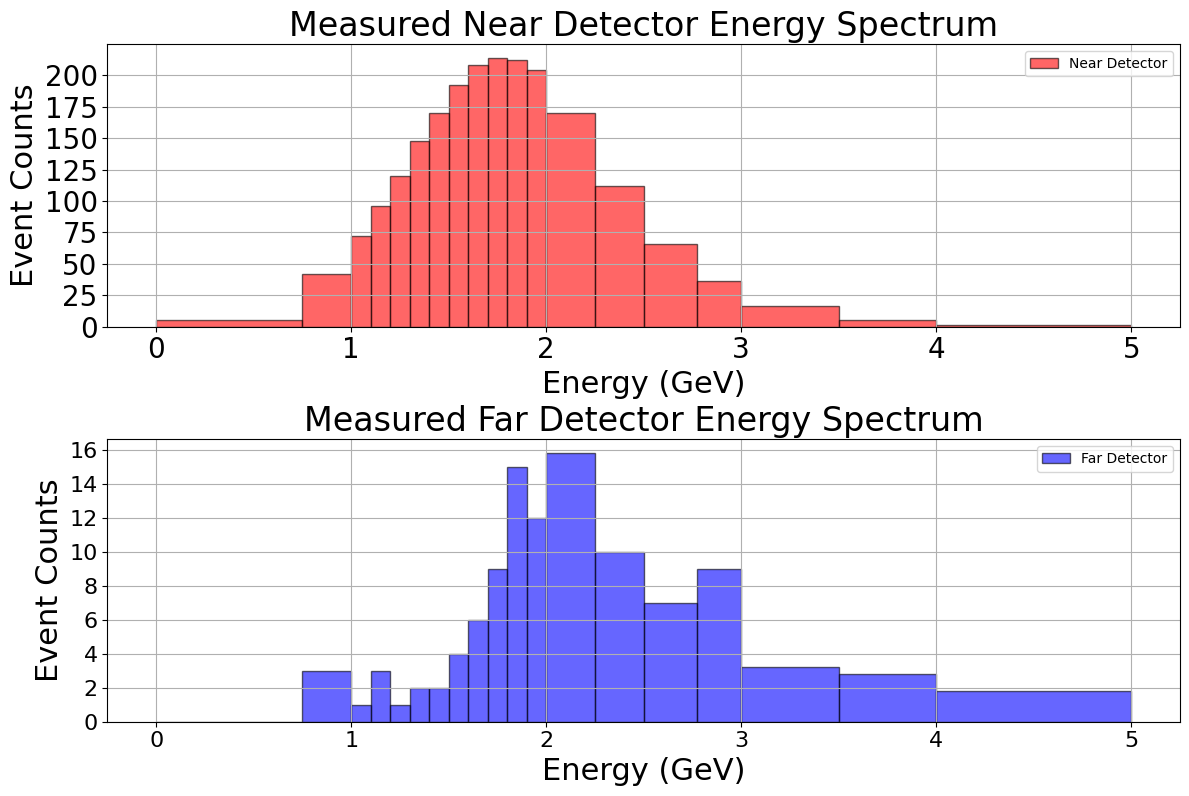

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Given Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Initialize the vacuum Hamiltonian
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute oscillation probabilities for muon neutrinos
def compute_probabilities_matter(baseline, energy_values):
    Prob_mu = []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt= probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)
    return np.array(Prob_mu)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

# Compute oscillation probabilities for the far detector
Prob_mu_far = compute_probabilities_matter(Length_far, bin_centers)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd = gaussian(bin_centers, *popt_nd) * Prob_mu_far / np.max(Prob_mu_far)

plt.figure(figsize=(12, 8))


# Plotting Near Detector Histogram
plt.subplot(2,1,1)
plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, align='center', alpha=0.6,color = 'red', edgecolor='black',label='Near Detector')
plt.xlabel("Energy (GeV)", fontsize = 22)
plt.ylabel("Event Counts",fontsize = 22)
plt.title("Measured Near Detector Energy Spectrum", fontsize = 24)
plt.grid()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend()



# Plotting Far Detector Histogram
plt.subplot(2, 1, 2)
plt.bar(bin_centers/ 1e9, counts_fd, width=np.diff(bin_edges)/ 1e9, align='center', alpha=0.6, label='Far Detector', color='blue', edgecolor = 'black')
plt.xlabel("Energy (GeV)", fontsize = 22)
plt.ylabel("Event Counts", fontsize = 22)
plt.title("Measured Far Detector Energy Spectrum", fontsize = 24)
plt.grid()
plt.legend()
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig("measured_count_spectra.png", dpi=300, bbox_inches='tight')
plt.show()



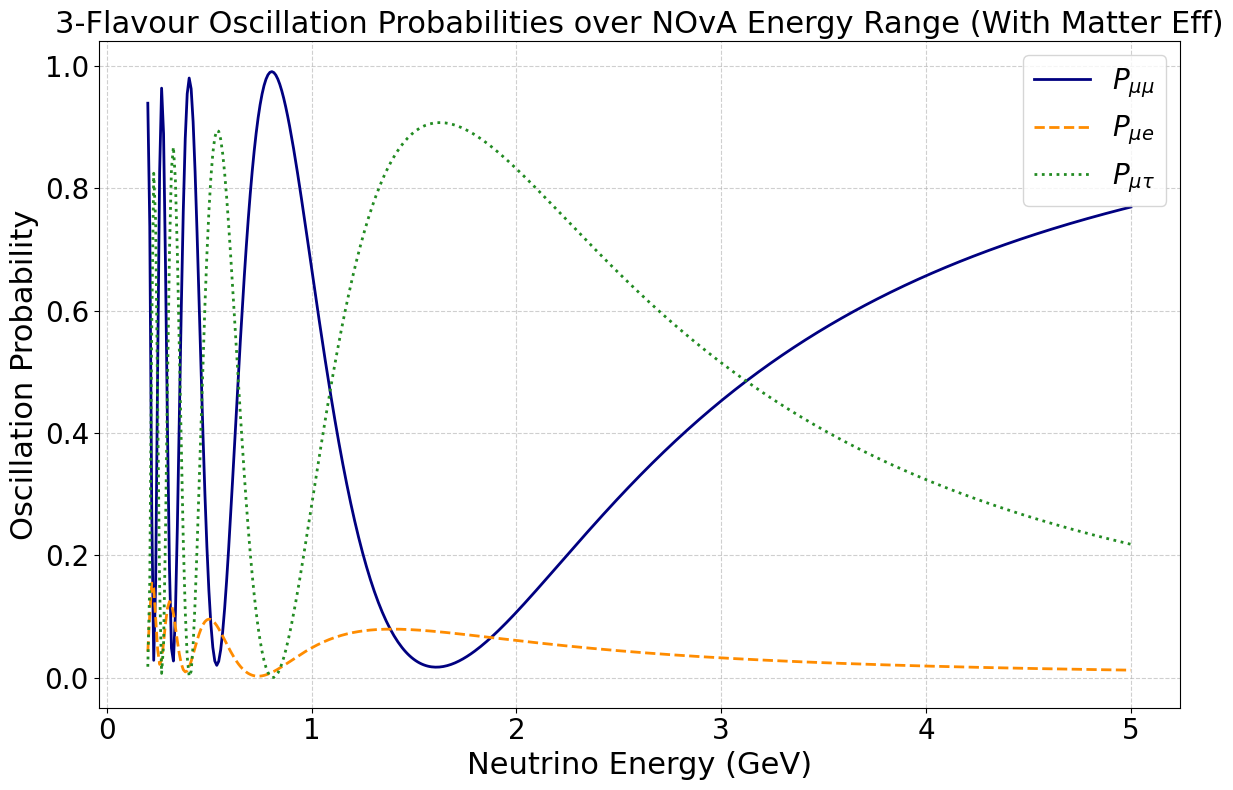

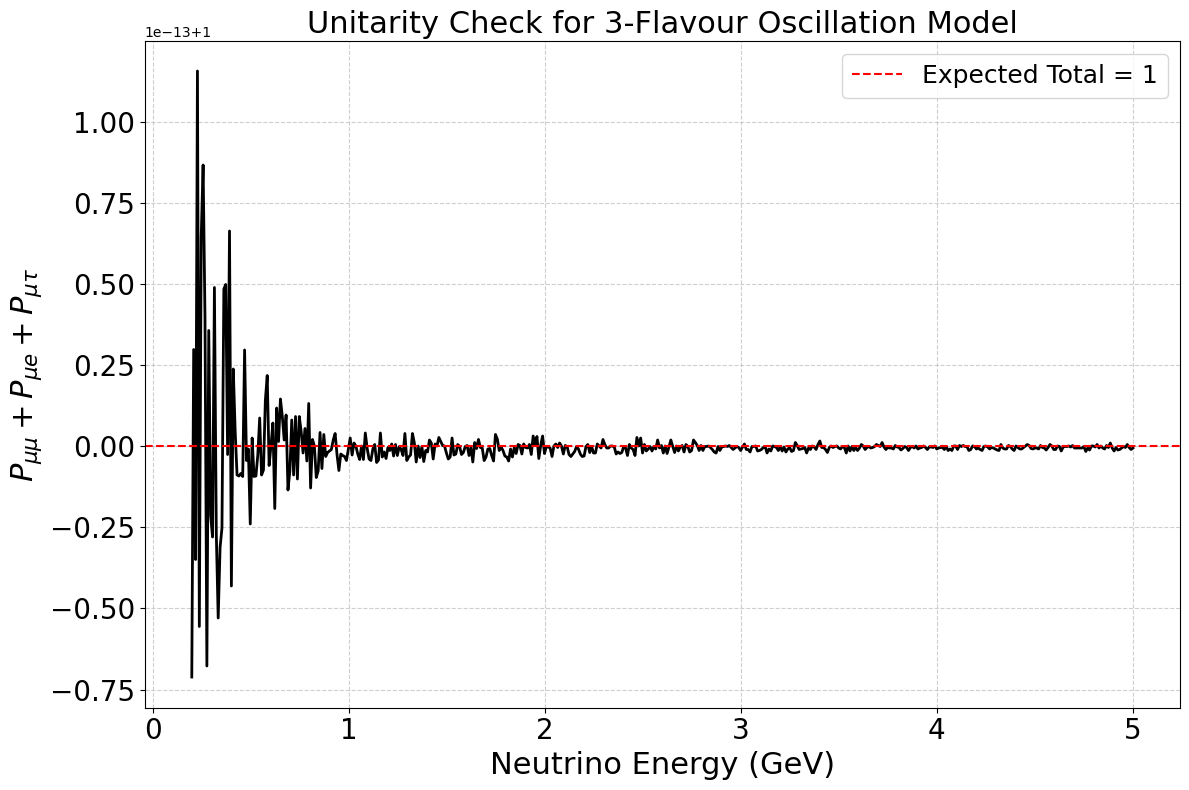

In [3]:
# Define energy range
energy_range = np.linspace(0.2e9, 5e9, 500)  # in eV

# Initialize arrays
prob_mm = []
prob_me = []
prob_mt = []
prob_sum = []

# Loop through energy values
for E in energy_range:
    h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
    Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, Length_far * CONV_KM_TO_INV_EV)

    # Store individual probabilities
    prob_mm.append(Pmm)
    prob_me.append(Pme)
    prob_mt.append(Pmt)

    # Unitarity check (should be ~1)
    prob_sum.append(Pmm + Pme + Pmt)

# Convert to arrays
prob_mm = np.array(prob_mm)
prob_me = np.array(prob_me)
prob_mt = np.array(prob_mt)
prob_sum = np.array(prob_sum)

# Plot all three oscillation channels
plt.figure(figsize=(12, 8))

plt.plot(energy_range / 1e9, prob_mm, label=r"$P_{\mu\mu}$", color='navy', linewidth=2)
plt.plot(energy_range / 1e9, prob_me, label=r"$P_{\mu e}$", color='darkorange', linestyle='--', linewidth=2)
plt.plot(energy_range / 1e9, prob_mt, label=r"$P_{\mu\tau}$", color='forestgreen', linestyle=':', linewidth=2)

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title("3-Flavour Oscillation Probabilities over NOvA Energy Range (With Matter Eff)", fontsize=22)
plt.legend(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("oscillation_validation_3flavour_allchannels.png", dpi=300, bbox_inches='tight')
plt.show()

# Unitarity Check Plot
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_sum, color='black', linewidth=2)
plt.axhline(1.0, color='red', linestyle='--', label="Expected Total = 1")
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel(r"$P_{\mu\mu} + P_{\mu e} + P_{\mu\tau}$", fontsize=22)
plt.title("Unitarity Check for 3-Flavour Oscillation Model", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("unitarity_check.png", dpi=300, bbox_inches='tight')
plt.show()


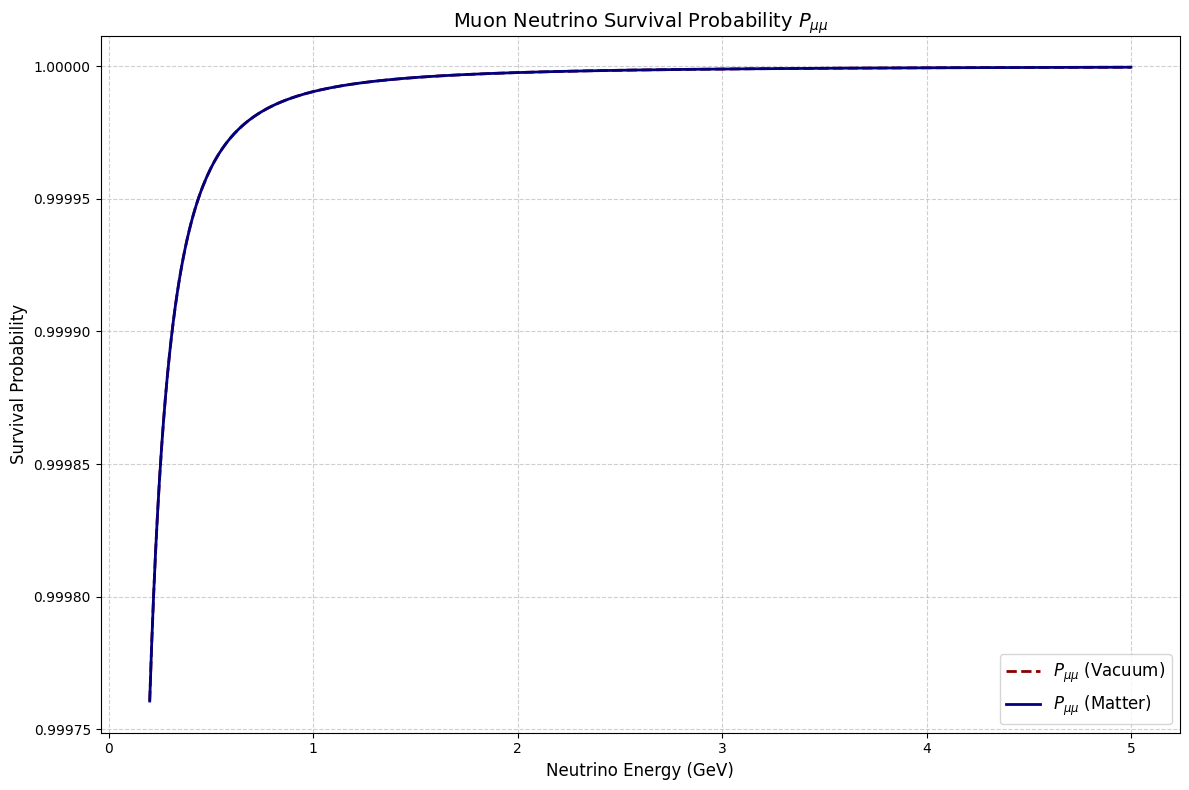

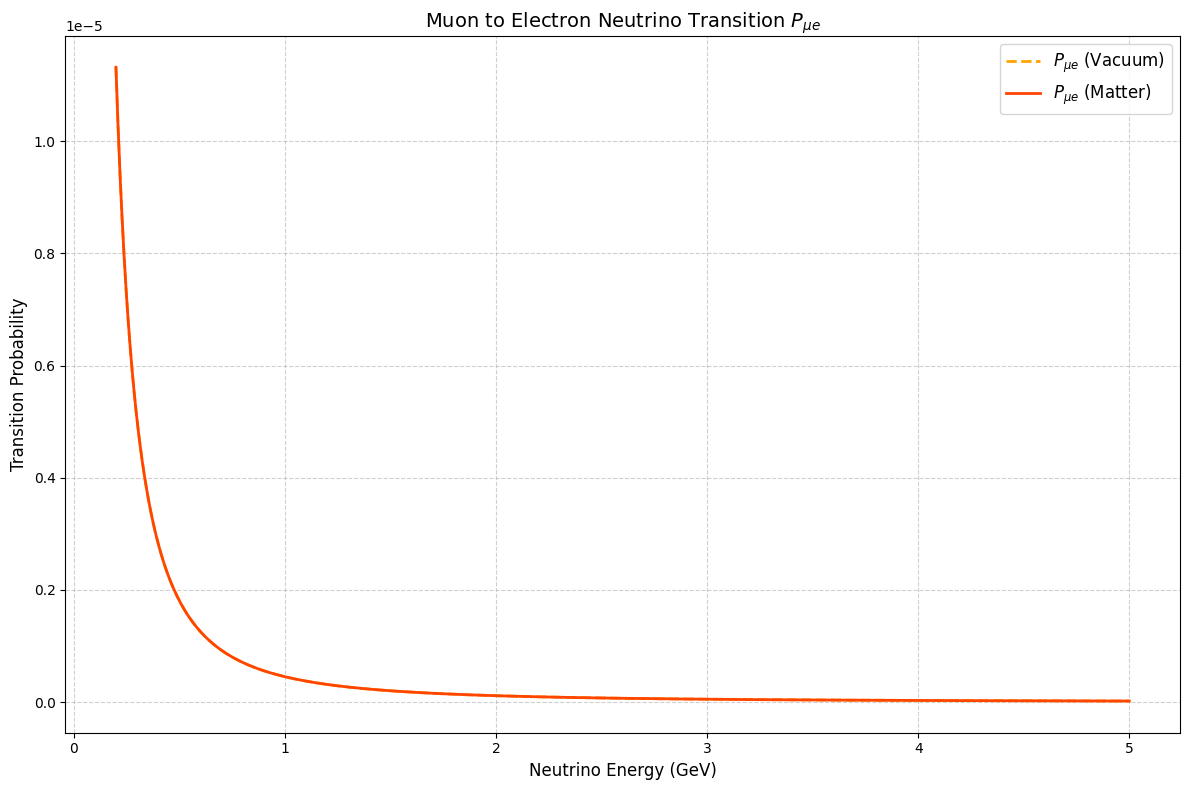

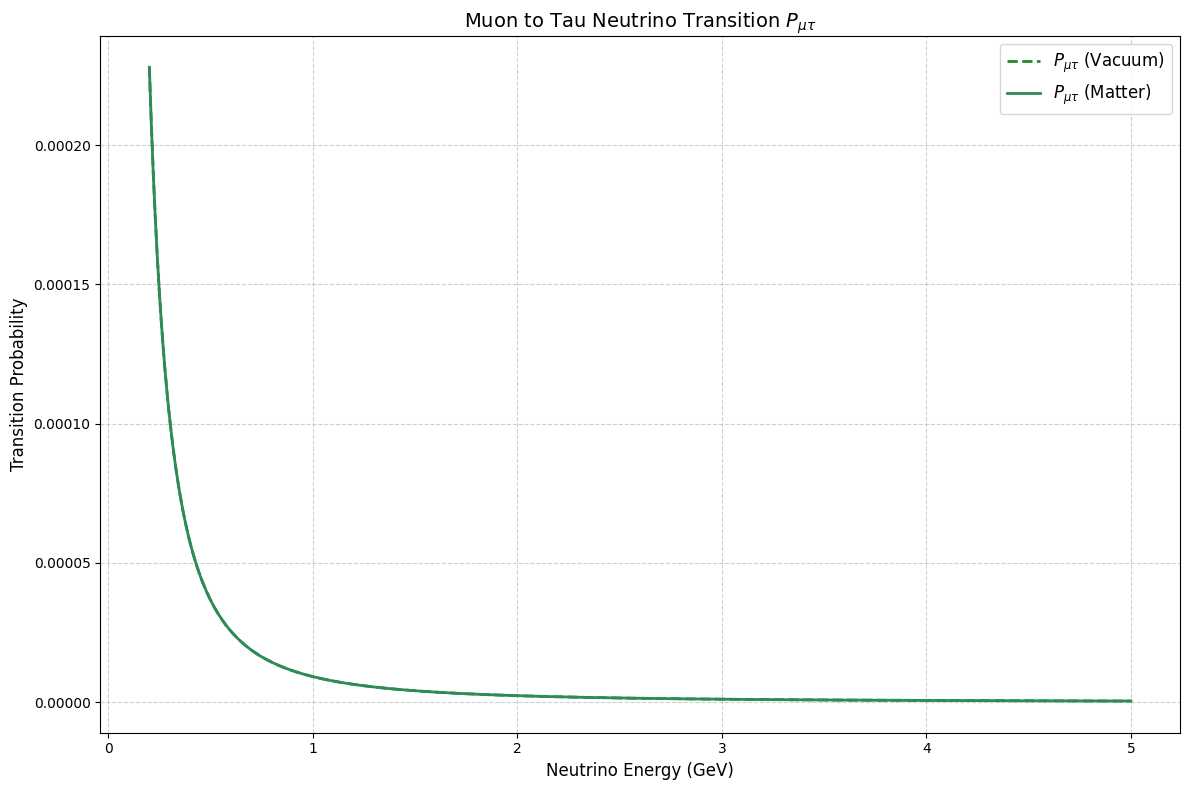

In [4]:
# Initialize arrays
prob_mm_vac = []
prob_mm_mat = []

prob_me_vac = []
prob_me_mat = []

prob_mt_vac = []
prob_mt_mat = []

# Calculate probabilities for both vacuum and matter
for E in energy_range:
    h_vac = h_vacuum_energy_indep / E
    _, _, _, Pme_v, Pmm_v, Pmt_v, _, _, _ = probabilities_3nu(h_vac, Length_near* CONV_KM_TO_INV_EV)

    prob_mm_vac.append(Pmm_v)
    prob_me_vac.append(Pme_v)
    prob_mt_vac.append(Pmt_v)

    h_mat = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
    _, _, _, Pme_m, Pmm_m, Pmt_m, _, _, _ = probabilities_3nu(h_mat, Length_near * CONV_KM_TO_INV_EV)

    prob_mm_mat.append(Pmm_m)
    prob_me_mat.append(Pme_m)
    prob_mt_mat.append(Pmt_m)

# Convert to arrays
prob_mm_vac = np.array(prob_mm_vac)
prob_mm_mat = np.array(prob_mm_mat)
prob_me_vac = np.array(prob_me_vac)
prob_me_mat = np.array(prob_me_mat)
prob_mt_vac = np.array(prob_mt_vac)
prob_mt_mat = np.array(prob_mt_mat)

# --- Figure 1: Muon Neutrino Survival ---
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_mm_vac, '--', color='darkred', linewidth=2, label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mm_mat, '-', color='navy', linewidth=2, label=r"$P_{\mu\mu}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.title(r"Muon Neutrino Survival Probability $P_{\mu\mu}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pmm_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2: Muon to Electron Neutrino Transition ---
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_me_vac, '--', color='orange', linewidth=2, label=r"$P_{\mu e}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_me_mat, '-', color='orangered', linewidth=2, label=r"$P_{\mu e}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Transition Probability", fontsize=12)
plt.title(r"Muon to Electron Neutrino Transition $P_{\mu e}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pme_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 3: Muon to Tau Neutrino Transition ---
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, prob_mt_vac, '--', color='forestgreen', linewidth=2, label=r"$P_{\mu\tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_mat, '-', color='seagreen', linewidth=2, label=r"$P_{\mu\tau}$ (Matter)")
plt.xlabel("Neutrino Energy (GeV)", fontsize=12)
plt.ylabel("Transition Probability", fontsize=12)
plt.title(r"Muon to Tau Neutrino Transition $P_{\mu\tau}$", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("pmt_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()





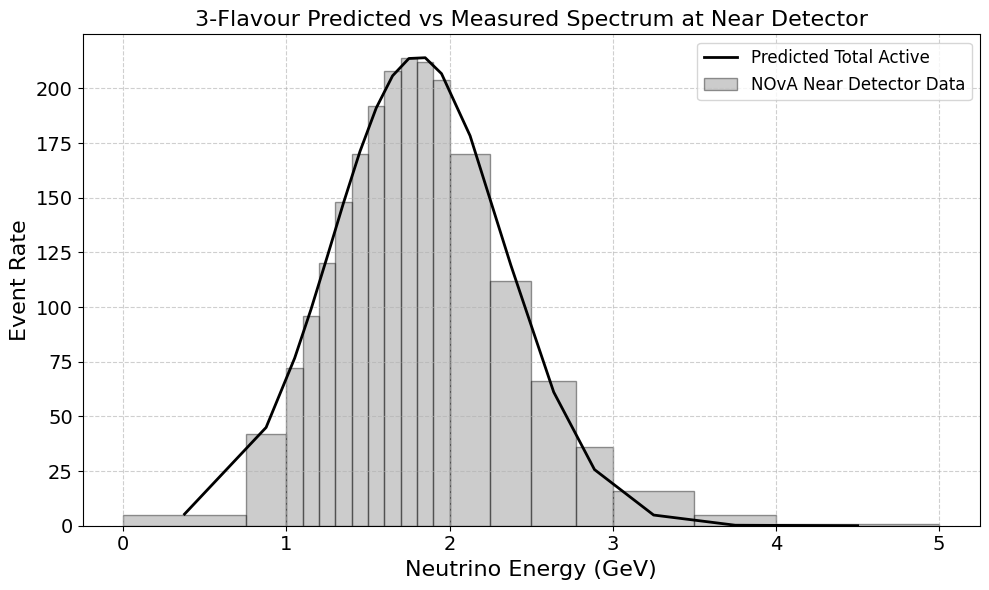

In [5]:
from scipy.interpolate import interp1d

# Step 1: Interpolate each probability to the bin centers of the Gaussian flux
interp_mm = interp1d(energy_range, prob_mm_mat, kind='linear')  # use matter or vacuum as needed
interp_me = interp1d(energy_range, prob_me_mat, kind='linear')
interp_mt = interp1d(energy_range, prob_mt_mat, kind='linear')

# Step 2: Evaluate at bin centers
prob_mm_bins = interp_mm(bin_centers)
prob_me_bins = interp_me(bin_centers)
prob_mt_bins = interp_mt(bin_centers)

# Step 3: Compute predicted spectra using the Gaussian flux
gaussian_flux = gaussian(bin_centers, *popt_nd)

spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins
spectrum_all = spectrum_mu + spectrum_e + spectrum_tau  # total active

total_measured = np.sum(counts_nd)  # Total observed at Near Detector
total_predicted = np.sum(spectrum_all)

scaling_factor = total_measured / total_predicted
spectrum_all_normalized = spectrum_all * scaling_factor

# Step 4: Plot overlayed with ND data
plt.figure(figsize=(10, 6))

plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9,
        alpha=0.4, label='NOvA Near Detector Data', color='gray', edgecolor='black')

plt.plot(bin_centers / 1e9, spectrum_all_normalized, color='black', linestyle='-', linewidth=2, label='Predicted Total Active')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Event Rate", fontsize=16)
plt.title("3-Flavour Predicted vs Measured Spectrum at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("3flavour_vs_data_near_detector.png", dpi=300, bbox_inches='tight')
plt.show()


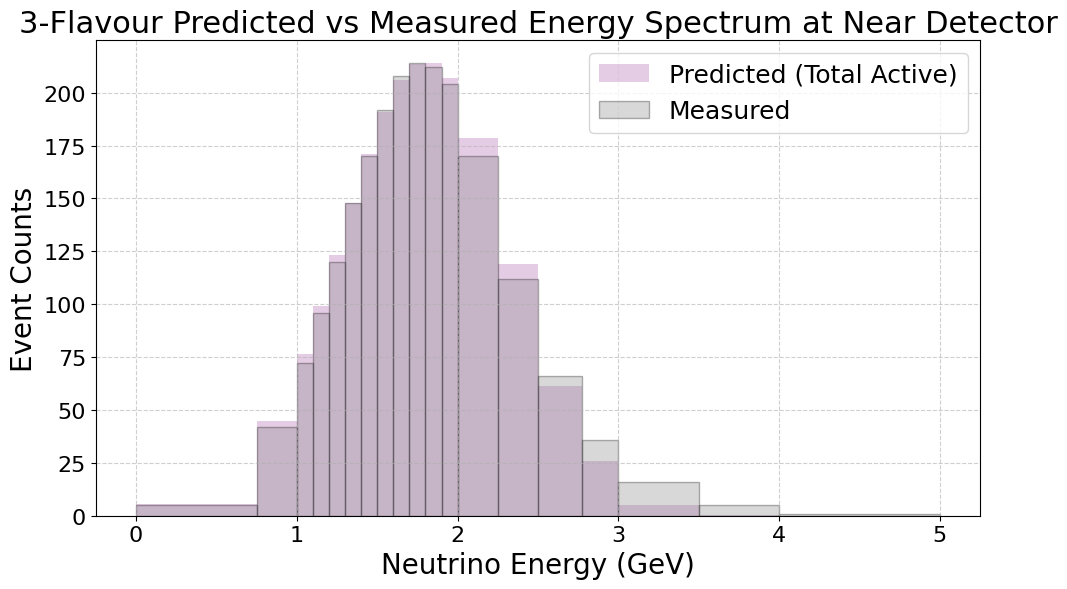

In [6]:
# Step 3: Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

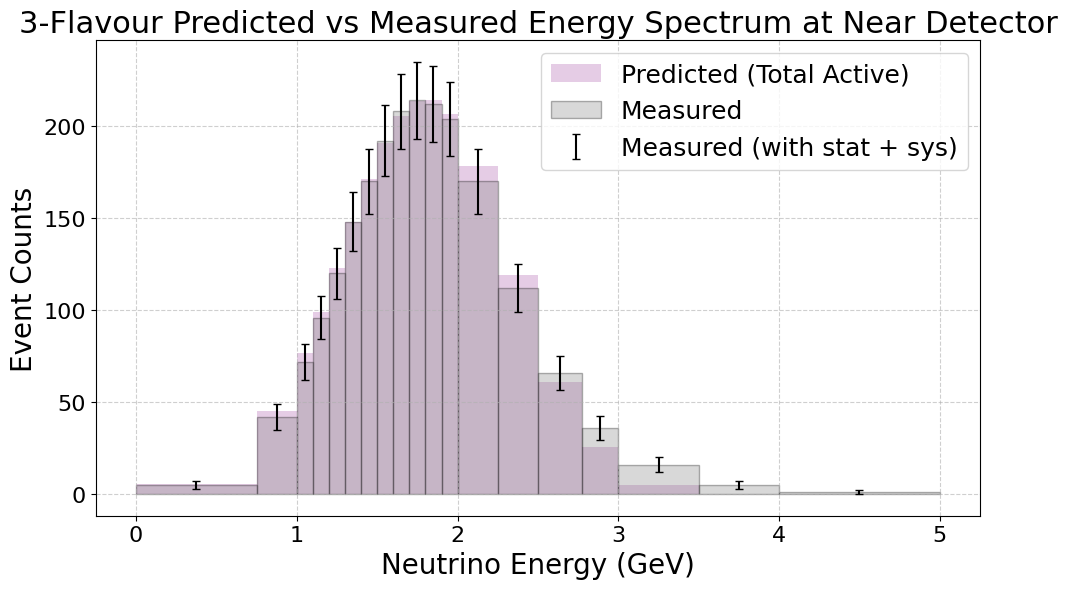

In [7]:
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)


# Step 3: Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)


# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram_with_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

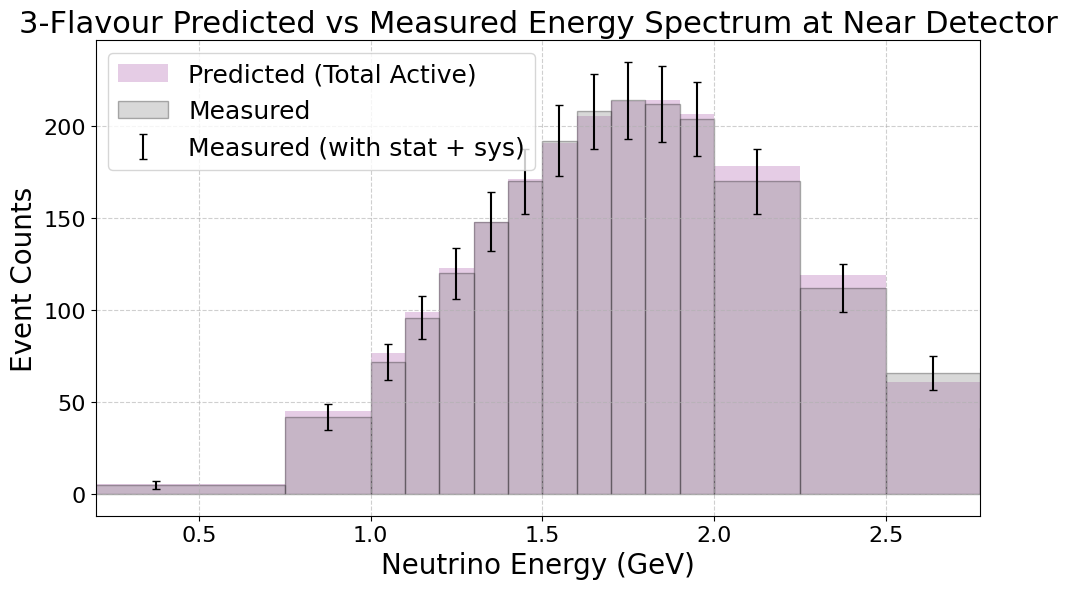

In [8]:
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)


# Step 3: Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)


# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.xlim(0.2,2.775)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram_with_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

[-0.31133486 -2.95804303 -4.6592022  -2.93917142 -3.15226298  0.16179595
 -1.15954108  0.88899229  2.20233379  0.27007063 -2.07225943 -2.78812592
 -8.38764113 -7.16305256  4.85660822 10.32043105 11.11733134  4.77348572
  0.9995856 ]


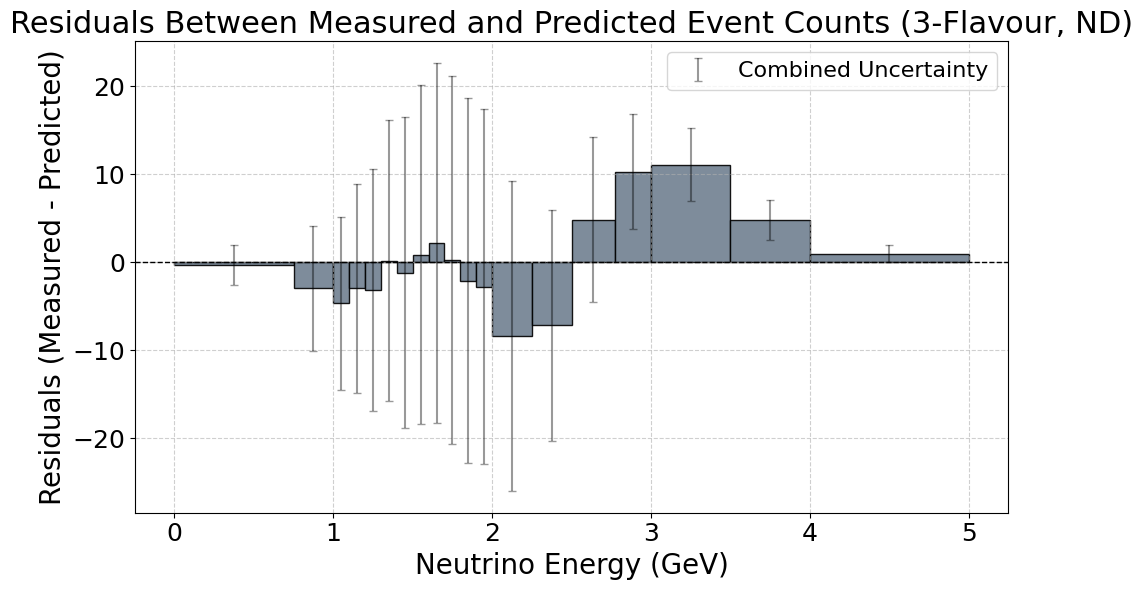

Scaling factor applied: 1.0099


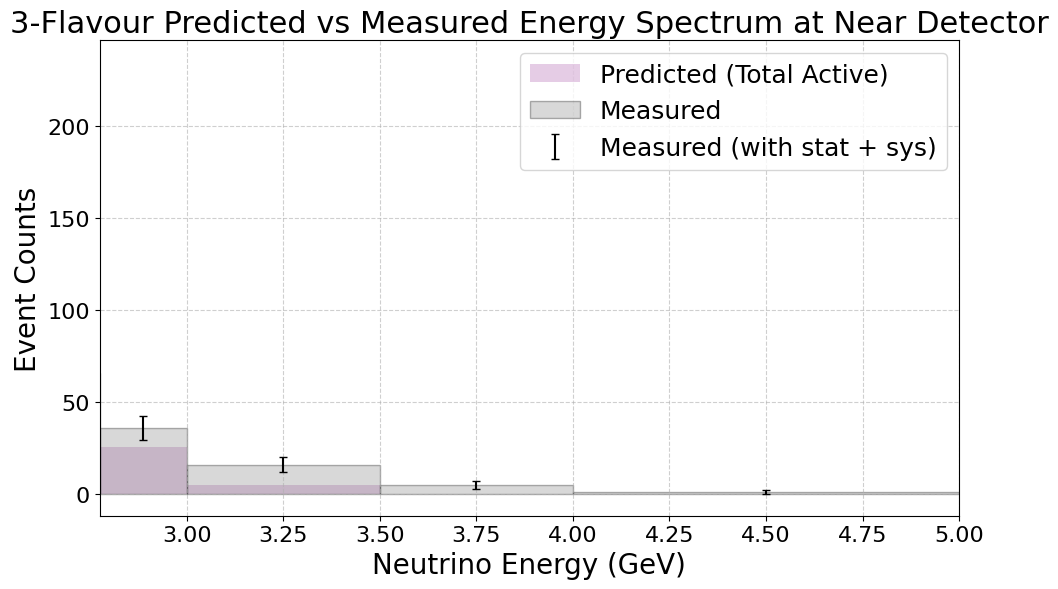

In [9]:
residuals = counts_nd - spectrum_all_normalized
print(residuals)

# Plot residuals
plt.figure(figsize=(10, 6))
plt.bar(bin_centers / 1e9, residuals, width=np.diff(bin_edges) / 1e9, color='slategrey', alpha=0.9, edgecolor='black')
plt.errorbar(bin_centers / 1e9, residuals, yerr=total_unc, fmt=' ', color='black', capsize=3, alpha = 0.4, label = 'Combined Uncertainty')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Residuals (Measured - Predicted)", fontsize=20)
plt.title("Residuals Between Measured and Predicted Event Counts (3-Flavour, ND)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize = 16)
plt.tight_layout()
plt.savefig("3flavour_residuals_ND.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Scaling factor applied: {scaling_factor:.4f}")
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)


# Step 3: Plot histograms (bar overlay)
plt.figure(figsize=(10, 6))

# Predicted (3-flavour) total active
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.2,
    color='purple',
    label='Predicted (Total Active)'
)

# Measured ND data
plt.bar(
    bin_centers / 1e9,
    counts_nd,
    width=np.diff(bin_edges) / 1e9,
    alpha=0.3,
    color='gray',
    edgecolor='black',
    label='Measured'
)

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)


# Labels & formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Event Counts", fontsize=20)
plt.title("3-Flavour Predicted vs Measured Energy Spectrum at Near Detector", fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.xlim(2.775,5.0)
plt.tight_layout()
plt.savefig("3flavour_predicted_vs_measured_ND_histogram_with_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

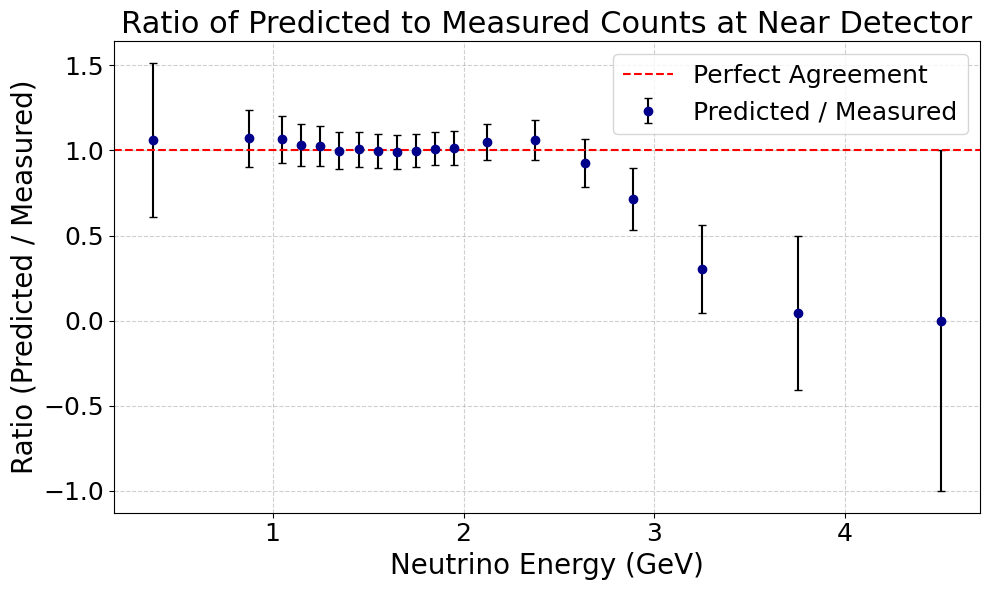

In [10]:
# 1. Avoid division by zero
mask = counts_nd > 0

# 2. Compute ratios and ratio uncertainties
ratios = np.full_like(counts_nd, np.nan, dtype=float)
ratio_unc = np.full_like(counts_nd, np.nan, dtype=float)

ratios[mask] = spectrum_all_normalized[mask] / counts_nd[mask]
ratio_unc[mask] = total_unc[mask] / counts_nd[mask]  # Relative uncertainty in ratio


plt.figure(figsize=(10, 6))

# Plot ratio with vertical error bars only
plt.errorbar(
    bin_centers / 1e9,
    ratios,
    yerr=ratio_unc,
    fmt='o',
    color='darkblue',
    ecolor='black',
    capsize=3,
    elinewidth=1.5,
    label='Predicted / Measured'
)

plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Perfect Agreement')

plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Ratio (Predicted / Measured)", fontsize=20)
plt.title("Ratio of Predicted to Measured Counts at Near Detector", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("ratio_predicted_measured_ND_errorbars.png", dpi=300, bbox_inches='tight')
plt.show()


In [11]:
import numpy as np
from scipy.stats import pearsonr

# Avoid zero divisions
mask = counts_nd > 0

# Corrected chi-squared using uncertainties
chi_squared = np.sum(((spectrum_all_normalized[mask] - counts_nd[mask])**2) / total_unc[mask]**2)
ndf = np.sum(mask) - 1
chi_squared_ndf = chi_squared / ndf

print(f"Chi-squared: {chi_squared:.2f}")
print(f"Chi-squared / NDF: {chi_squared_ndf:.2f}")

# MAE and RMSE are still fine as-is
mae = np.mean(np.abs(spectrum_all_normalized - counts_nd))
print(f"Mean Absolute Error (MAE): {mae:.2f}")

rmse = np.sqrt(np.mean((spectrum_all_normalized - counts_nd)**2))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Pearson correlation coefficient (still valid)
r_value, _ = pearsonr(spectrum_all_normalized, counts_nd)
print(f"Pearson Correlation Coefficient: {r_value:.3f}")



Chi-squared: 16.49
Chi-squared / NDF: 0.92
Mean Absolute Error (MAE): 3.75
Root Mean Squared Error (RMSE): 4.96
Pearson Correlation Coefficient: 0.998


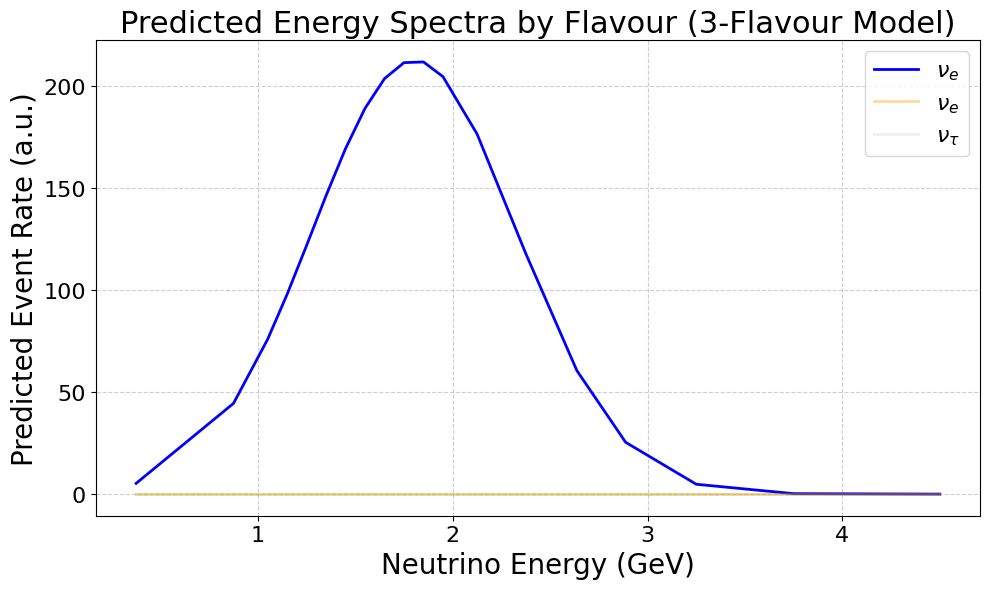

In [12]:
# Plot the individual spectra
plt.figure(figsize=(10, 6))
plt.plot(bin_centers / 1e9, spectrum_mu, label=r"$\nu_e$", color='blue', linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_e, label=r"$\nu_e$", color='orange', linewidth=2, alpha = 0.4)
plt.plot(bin_centers / 1e9, spectrum_tau, label=r"$\nu_\tau$", color='forestgreen',alpha = 0.1, linewidth=2)

plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=20)
plt.title("Predicted Energy Spectra by Flavour (3-Flavour Model)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("3flavour_predicted_spectra_by_flavour_all.png", dpi=300, bbox_inches='tight')
plt.show()

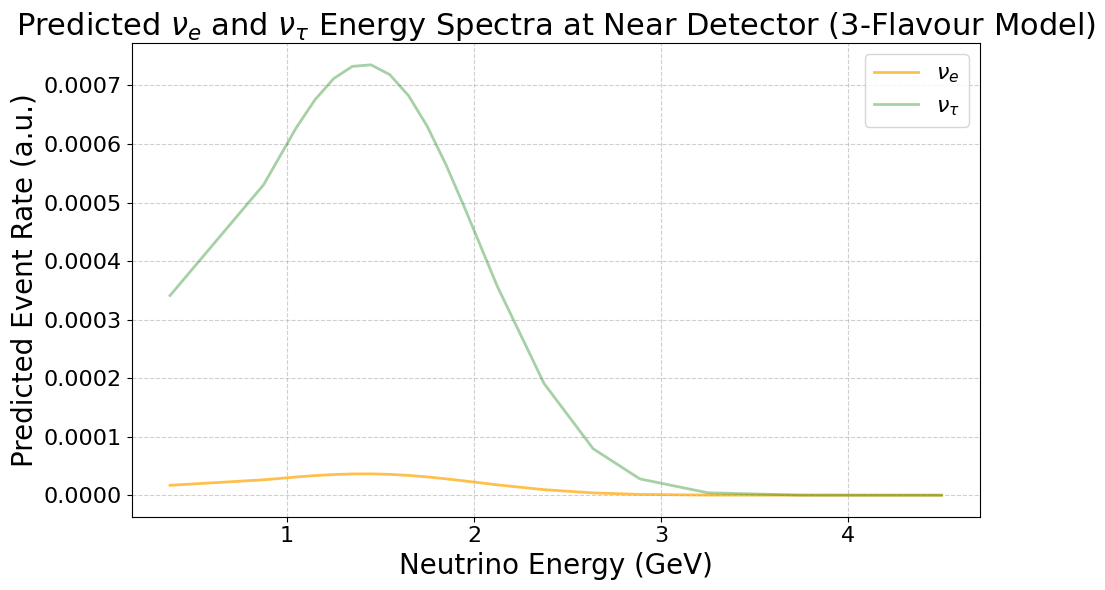

In [13]:
# Compute individual spectra
spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins

# Plot the individual spectra
plt.figure(figsize=(10, 6))

plt.plot(bin_centers / 1e9, spectrum_e, label=r"$\nu_e$", color='orange', linewidth=2, alpha = 0.7)
plt.plot(bin_centers / 1e9, spectrum_tau, label=r"$\nu_\tau$", color='forestgreen',alpha = 0.4, linewidth=2)

plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=20)
plt.title(r"Predicted $\nu_e$ and $\nu_\tau$ Energy Spectra at Near Detector (3-Flavour Model)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("3flavour_predicted_spectra_by_flavour_e_and_tau.png", dpi=300, bbox_inches='tight')
plt.show()


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Constants
CONV_KM_TO_INV_EV = 5.067731e9  # Conversion factor from km to inverse eV
VCC_EARTH_CRUST = 7.6e-14  # Matter potential in eV

# Define mixing matrix elements
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

# Define Hamiltonians
def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])  # Mass squared differences
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    H_vacuum = U @ m2_diag @ np.conj(U.T) / (2 * E)
    return H_vacuum

def hamiltonian_4nu_matter(H_vacuum, E, VCC):
    H_matter = H_vacuum + np.diag([VCC, 0, 0, 0])
    return H_matter

# Compute probabilities
def probabilities_4nu_vacuum(H_vacuum, baseline):
    H_t = -1j * H_vacuum * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    Pme = np.abs(S[1, 0])**2  # Muon to electron
    Pmt = np.abs(S[1, 2])**2  # Muon to tau
    Pms = np.abs(S[1, 3])**2  # Muon to sterile
    return Pmm, Pme, Pmt, Pms

def probabilities_4nu_matter(H_matter, baseline):
    H_t = -1j * H_matter * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    Pme = np.abs(S[1, 0])**2  # Muon to electron
    Pmt = np.abs(S[1, 2])**2  # Muon to tau
    Pms = np.abs(S[1, 3])**2  # Muon to sterile
    return Pmm, Pme, Pmt, Pms

# Compute oscillation probabilities
def compute_probabilities(baseline, energy_values, matter = False):
    Prob_mm, Prob_me, Prob_mt, Prob_ms = [], [], [], []
    for E in energy_values:
        #Compute vacuum hamiltonian
        H_vacuum = hamiltonian_4nu_vacuum(
            theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E
        )

        if matter:
          #Compute matter hamiltonian if matter effects included
          H_matter = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
          Pmm, Pme, Pmt, Pms = probabilities_4nu_matter(H_matter, baseline * CONV_KM_TO_INV_EV)


        else:
          #Vacuum oscillations if no matter effects
          Pmm, Pme, Pmt, Pms = probabilities_4nu_vacuum(H_vacuum, baseline * CONV_KM_TO_INV_EV)



        Prob_mm.append(Pmm)
        Prob_me.append(Pme)
        Prob_mt.append(Pmt)
        Prob_ms.append(Pms)
    return np.array(Prob_mm), np.array(Prob_me), np.array(Prob_mt), np.array(Prob_ms)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Oscillation Parameters (Updated to best-fit values from global sterile neutrino fits)
theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])       # Standard PMNS angles
theta14, theta24, theta34 = np.radians([7.2, 9.2, 0.0])           # Best-fit sterile angles
delta13, delta14 = np.radians([0, 0])                             # CP-violating phases (neglected here)
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.3]                           # Mass squared differences in eV^2


# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

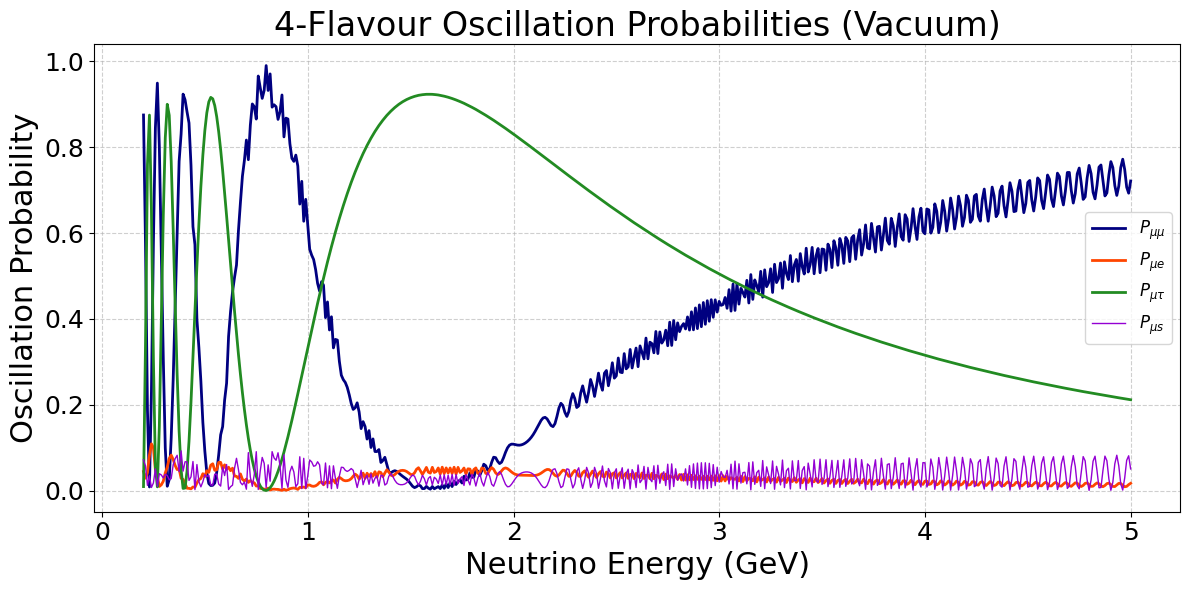

In [15]:
# Define continuous energy range
energy_range = np.linspace(0.2e9, 5e9, 500)  # in eV

# Compute probabilities over continuous range
prob_mm_vac, prob_me_vac, prob_mt_vac, prob_ms_vac = compute_probabilities(
    baseline=Length_far,
    energy_values=energy_range,
    matter=False
)



# Plotting
plt.figure(figsize=(12, 6))

plt.plot(energy_range / 1e9, prob_mm_vac, '-', linewidth=2, label=r"$P_{\mu\mu}$", color="navy")
plt.plot(energy_range / 1e9, prob_me_vac, '-', linewidth=2, label=r"$P_{\mu e}$", color="orangered")
plt.plot(energy_range / 1e9, prob_mt_vac, '-', linewidth=2, label=r"$P_{\mu \tau}$", color="forestgreen")
plt.plot(energy_range / 1e9, prob_ms_vac, '-', linewidth=1, label=r"$P_{\mu s}$", color="darkviolet")

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title("4-Flavour Oscillation Probabilities (Vacuum)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_oscillation_probabilities_vacuum.png", dpi=300, bbox_inches='tight')
plt.show()


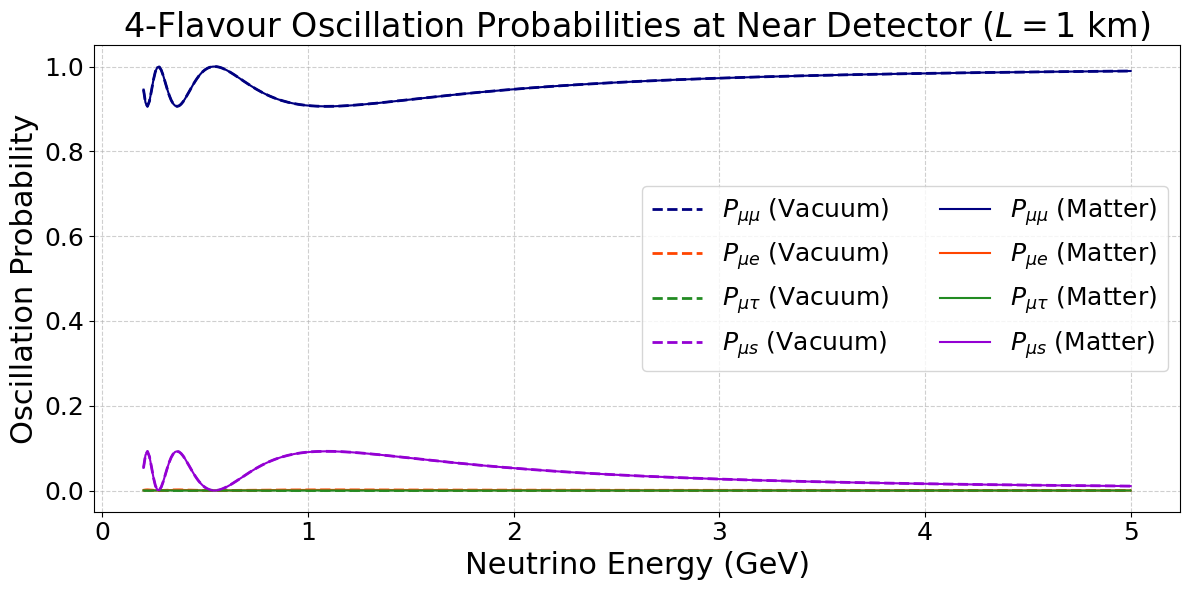

In [16]:
# Compute 4-flavour oscillation probabilities at the Near Detector
prob_mm_near_vac, prob_me_near_vac, prob_mt_near_vac, prob_ms_near_vac = compute_probabilities(
    baseline=Length_near, energy_values=energy_range, matter=False)

prob_mm_near_mat, prob_me_near_mat, prob_mt_near_mat, prob_ms_near_mat = compute_probabilities(
    baseline=Length_near, energy_values=energy_range, matter=True)

# Plot
plt.figure(figsize=(12, 6))

# Survival and transition probabilities - Vacuum
plt.plot(energy_range / 1e9, prob_mm_near_vac, '--', linewidth=2, color='navy', label=r"$P_{\mu\mu}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_me_near_vac, '--', linewidth=2, color='orangered', label=r"$P_{\mu e}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_near_vac, '--', linewidth=2, color='forestgreen', label=r"$P_{\mu \tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_ms_near_vac, '--', linewidth=2, color='darkviolet', label=r"$P_{\mu s}$ (Vacuum)")

# Survival and transition probabilities - Matter
plt.plot(energy_range / 1e9, prob_mm_near_mat, '-', linewidth=1.5, color='navy', label=r"$P_{\mu\mu}$ (Matter)")
plt.plot(energy_range / 1e9, prob_me_near_mat, '-', linewidth=1.5, color='orangered', label=r"$P_{\mu e}$ (Matter)")
plt.plot(energy_range / 1e9, prob_mt_near_mat, '-', linewidth=1.5, color='forestgreen', label=r"$P_{\mu \tau}$ (Matter)")
plt.plot(energy_range / 1e9, prob_ms_near_mat, '-', linewidth=1.5, color='darkviolet', label=r"$P_{\mu s}$ (Matter)")

# Formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title(r"4-Flavour Oscillation Probabilities at Near Detector ($L=1$ km)", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18, ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_probabilities_near_detector_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()


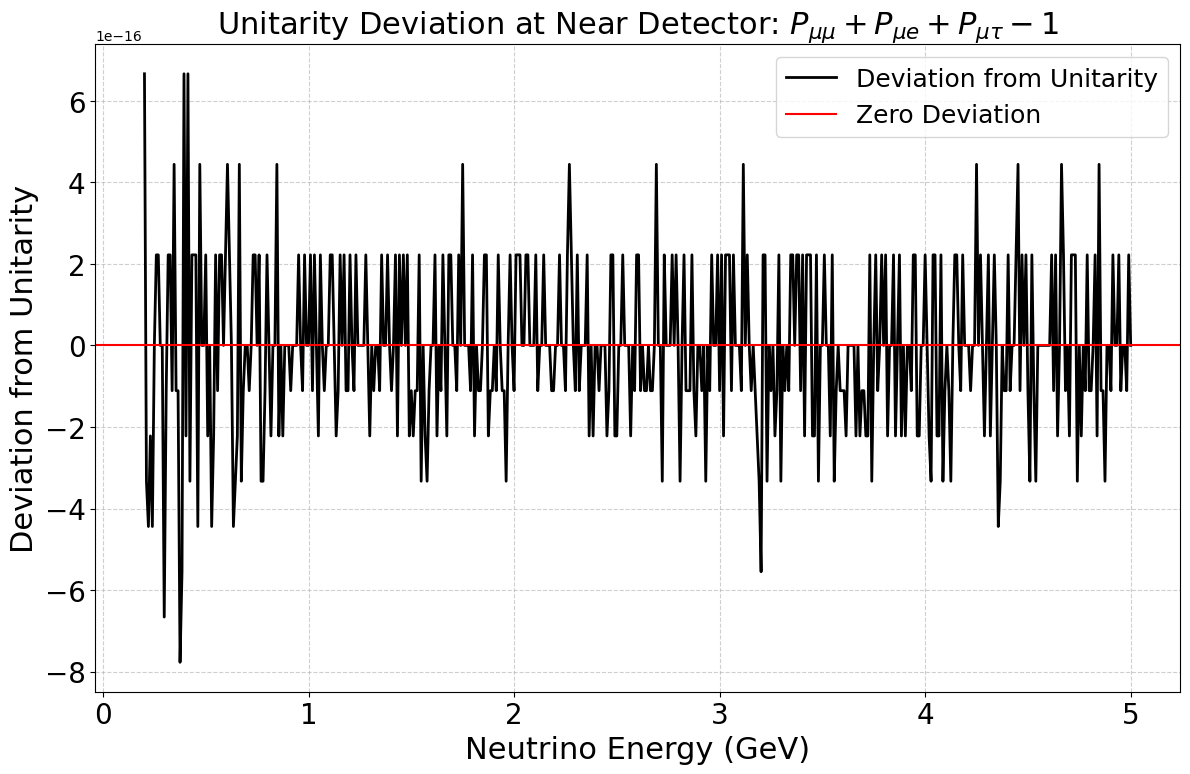

In [17]:
# First compute sum of active probabilities (in vacuum)
prob_sum_active = prob_mm_near_vac + prob_me_near_vac + prob_mt_near_vac+ prob_ms_near_vac

# Deviation from unitarity
deviation = prob_sum_active - 1  # This should be ~ -P_{μs} in the 4-flavour case

# Plot deviation
plt.figure(figsize=(12, 8))
plt.plot(energy_range / 1e9, deviation, color='black', linewidth=2, label="Deviation from Unitarity")
plt.axhline(0, color='red', linestyle='-', label="Zero Deviation")
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel(r"Deviation from Unitarity", fontsize=22)
plt.title(r"Unitarity Deviation at Near Detector: $P_{\mu\mu} + P_{\mu e} + P_{\mu\tau} - 1$", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("unitarity_deviation_4flavour_near.png", dpi=300, bbox_inches='tight')
plt.show()


In [18]:
from google.colab import files
files.download('unitarity_deviation_4flavour_near.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

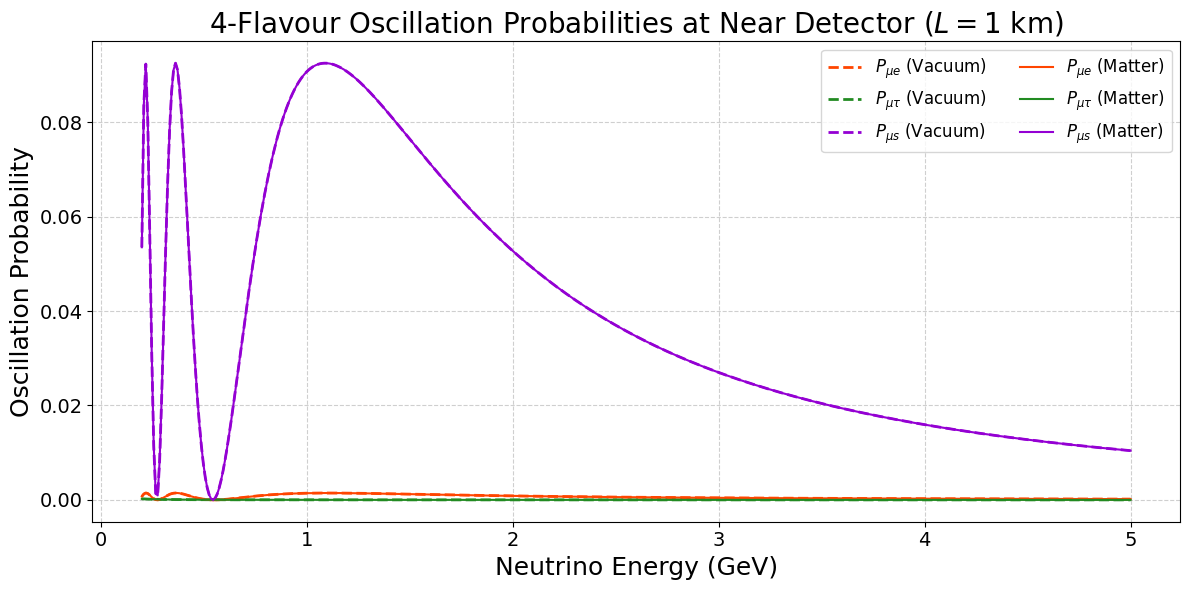

In [19]:
plt.figure(figsize=(12, 6))

# Survival and transition probabilities - Vacuum

plt.plot(energy_range / 1e9, prob_me_near_vac, '--', linewidth=2, color='orangered', label=r"$P_{\mu e}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_mt_near_vac, '--', linewidth=2, color='forestgreen', label=r"$P_{\mu \tau}$ (Vacuum)")
plt.plot(energy_range / 1e9, prob_ms_near_vac, '--', linewidth=2, color='darkviolet', label=r"$P_{\mu s}$ (Vacuum)")

# Survival and transition probabilities - Matter

plt.plot(energy_range / 1e9, prob_me_near_mat, '-', linewidth=1.5, color='orangered', label=r"$P_{\mu e}$ (Matter)")
plt.plot(energy_range / 1e9, prob_mt_near_mat, '-', linewidth=1.5, color='forestgreen', label=r"$P_{\mu \tau}$ (Matter)")
plt.plot(energy_range / 1e9, prob_ms_near_mat, '-', linewidth=1.5, color='darkviolet', label=r"$P_{\mu s}$ (Matter)")

# Formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Oscillation Probability", fontsize=18)
plt.title(r"4-Flavour Oscillation Probabilities at Near Detector ($L=1$ km)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_probabilities_near_detector_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

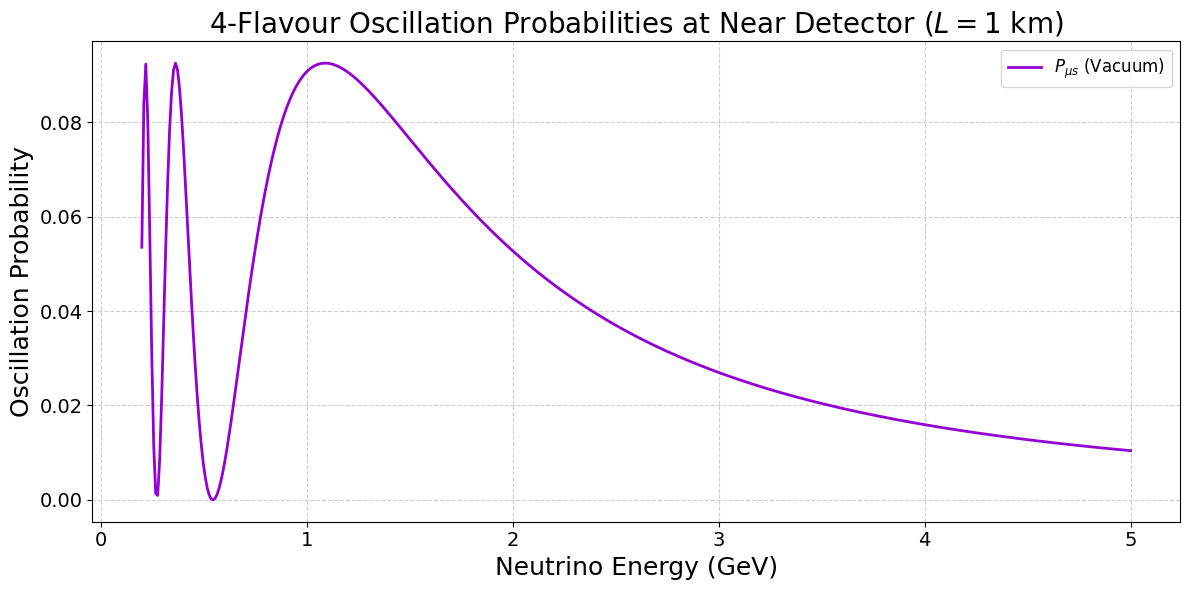

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(energy_range / 1e9, prob_ms_near_vac, '-', linewidth=2, color='darkviolet', label=r"$P_{\mu s}$ (Vacuum)")

# Formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Oscillation Probability", fontsize=18)
plt.title(r"4-Flavour Oscillation Probabilities at Near Detector ($L=1$ km)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_probabilities_near_detector_vacuum_vs_matter.png", dpi=300, bbox_inches='tight')
plt.show()

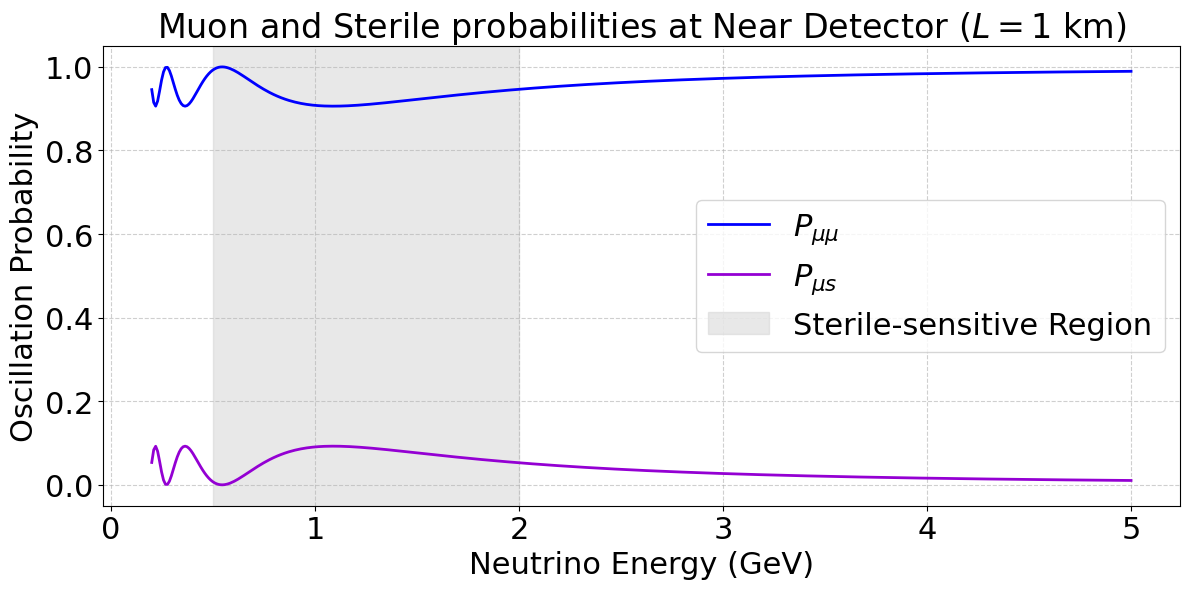

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(energy_range / 1e9, prob_mm_near_vac, '-', linewidth=2, color='blue', label=r"$P_{\mu\mu}$ ")
plt.plot(energy_range / 1e9, prob_ms_near_vac, '-', linewidth=2, color='darkviolet', label=r"$P_{\mu s}$")
plt.axvspan(0.5, 2.0, color='lightgray', alpha=0.5, label='Sterile-sensitive Region')

# Formatting
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Oscillation Probability", fontsize=22)
plt.title(r"Muon and Sterile probabilities at Near Detector ($L=1$ km)", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("4flavour_muon_sterile_key_area_near_detector_.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
from google.colab import files
files.download('4flavour_muon_sterile_key_area_near_detector_.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
max_prob_mm = np.max(prob_mm_near_vac)
energy_at_max_mm = energy_range[np.argmax(prob_mm_near_vac)] / 1e9  # in GeV

max_prob_ms = np.max(prob_ms_near_vac)
energy_at_max_ms = energy_range[np.argmax(prob_ms_near_vac)] / 1e9  # in GeV

(max_prob_mm, energy_at_max_mm), (max_prob_ms, energy_at_max_ms)

# Calculate the absolute difference
difference = np.abs(prob_mm_near_vac - prob_ms_near_vac)

# Find the index where the difference is smallest
min_diff_index = np.argmin(difference)
min_diff_energy = energy_range[min_diff_index] / 1e9  # Convert to GeV
min_diff_value = difference[min_diff_index]

# Print results
print(f"Minimum difference between P_mu_mu and P_mu_s is {min_diff_value:.5f} at {min_diff_energy:.3f} GeV")

# Optionally: values at that point
print(f"P_mu_mu = {prob_mm_near_vac[min_diff_index]:.5f}")
print(f"P_mu_s  = {prob_ms_near_vac[min_diff_index]:.5f}")

Minimum difference between P_mu_mu and P_mu_s is 0.81348 at 0.364 GeV
P_mu_mu = 0.90598
P_mu_s  = 0.09250


In [24]:
import numpy as np

# Find all indices where P_mu_s > 0.9
indices_above_90 = np.where(prob_ms_near_vac > 0.09)[0]

# Print results
print(f"Found {len(indices_above_90)} energy values where P_mu_s > 0.9:\n")
for idx in indices_above_90:
    energy_gev = energy_range[idx] / 1e9
    p_ms_value = prob_ms_near_vac[idx]
    print(f"Energy = {energy_gev:.4f} GeV, P_mu_s = {p_ms_value:.4f}")


Found 28 energy values where P_mu_s > 0.9:

Energy = 0.2192 GeV, P_mu_s = 0.0923
Energy = 0.3539 GeV, P_mu_s = 0.0911
Energy = 0.3635 GeV, P_mu_s = 0.0925
Energy = 0.3731 GeV, P_mu_s = 0.0911
Energy = 0.9888 GeV, P_mu_s = 0.0901
Energy = 0.9984 GeV, P_mu_s = 0.0906
Energy = 1.0080 GeV, P_mu_s = 0.0910
Energy = 1.0176 GeV, P_mu_s = 0.0914
Energy = 1.0273 GeV, P_mu_s = 0.0917
Energy = 1.0369 GeV, P_mu_s = 0.0919
Energy = 1.0465 GeV, P_mu_s = 0.0921
Energy = 1.0561 GeV, P_mu_s = 0.0923
Energy = 1.0657 GeV, P_mu_s = 0.0924
Energy = 1.0754 GeV, P_mu_s = 0.0925
Energy = 1.0850 GeV, P_mu_s = 0.0925
Energy = 1.0946 GeV, P_mu_s = 0.0925
Energy = 1.1042 GeV, P_mu_s = 0.0925
Energy = 1.1138 GeV, P_mu_s = 0.0924
Energy = 1.1234 GeV, P_mu_s = 0.0923
Energy = 1.1331 GeV, P_mu_s = 0.0922
Energy = 1.1427 GeV, P_mu_s = 0.0920
Energy = 1.1523 GeV, P_mu_s = 0.0918
Energy = 1.1619 GeV, P_mu_s = 0.0916
Energy = 1.1715 GeV, P_mu_s = 0.0914
Energy = 1.1812 GeV, P_mu_s = 0.0911
Energy = 1.1908 GeV, P_mu_s = 0

In [25]:
import numpy as np

# Find all indices where P_mu_s > 0.9
indices_below_90 = np.where(prob_mm_near_vac < 0.91)[0]

# Print results
print(f"Found {len(indices_above_90)} energy values where P_mu_s < 0.9:\n")
for idx in indices_above_90:
    energy_gev = energy_range[idx] / 1e9
    p_mm_value = prob_mm_near_vac[idx]
    print(f"Energy = {energy_gev:.4f} GeV, P_mu_s = {p_mm_value:.4f}")

Found 28 energy values where P_mu_s < 0.9:

Energy = 0.2192 GeV, P_mu_s = 0.9060
Energy = 0.3539 GeV, P_mu_s = 0.9075
Energy = 0.3635 GeV, P_mu_s = 0.9060
Energy = 0.3731 GeV, P_mu_s = 0.9074
Energy = 0.9888 GeV, P_mu_s = 0.9085
Energy = 0.9984 GeV, P_mu_s = 0.9080
Energy = 1.0080 GeV, P_mu_s = 0.9076
Energy = 1.0176 GeV, P_mu_s = 0.9072
Energy = 1.0273 GeV, P_mu_s = 0.9069
Energy = 1.0369 GeV, P_mu_s = 0.9066
Energy = 1.0465 GeV, P_mu_s = 0.9064
Energy = 1.0561 GeV, P_mu_s = 0.9063
Energy = 1.0657 GeV, P_mu_s = 0.9062
Energy = 1.0754 GeV, P_mu_s = 0.9061
Energy = 1.0850 GeV, P_mu_s = 0.9060
Energy = 1.0946 GeV, P_mu_s = 0.9060
Energy = 1.1042 GeV, P_mu_s = 0.9061
Energy = 1.1138 GeV, P_mu_s = 0.9061
Energy = 1.1234 GeV, P_mu_s = 0.9062
Energy = 1.1331 GeV, P_mu_s = 0.9064
Energy = 1.1427 GeV, P_mu_s = 0.9065
Energy = 1.1523 GeV, P_mu_s = 0.9067
Energy = 1.1619 GeV, P_mu_s = 0.9069
Energy = 1.1715 GeV, P_mu_s = 0.9072
Energy = 1.1812 GeV, P_mu_s = 0.9074
Energy = 1.1908 GeV, P_mu_s = 0

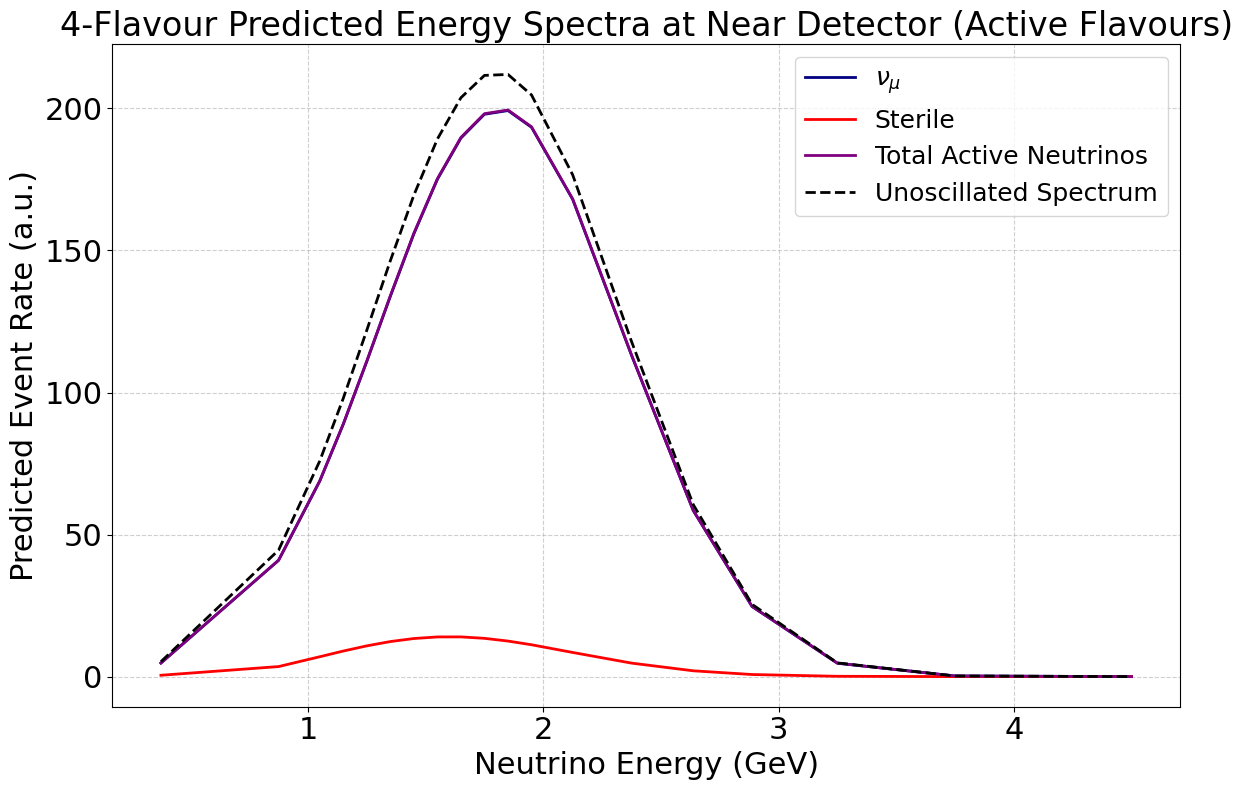

In [26]:
from scipy.interpolate import interp1d

# Interpolate 4-flavour vacuum probabilities at bin_centers
interp_mm = interp1d(energy_range, prob_mm_near_vac, kind='linear')
interp_me = interp1d(energy_range, prob_me_near_vac, kind='linear')
interp_mt = interp1d(energy_range, prob_mt_near_vac, kind='linear')
interp_ms = interp1d(energy_range, prob_ms_near_vac, kind='linear')

#Evaluate interpolated probabilities at bin centers
prob_mm_bins = interp_mm(bin_centers)
prob_me_bins = interp_me(bin_centers)
prob_mt_bins = interp_mt(bin_centers)
prob_ms_bins = interp_ms(bin_centers)



#Get unoscillated input spectrum
gaussian_flux = gaussian(bin_centers, *popt_nd)

# Compute predicted spectra for each active flavour
spectrum_mu = gaussian_flux * prob_mm_bins
spectrum_e  = gaussian_flux * prob_me_bins
spectrum_tau = gaussian_flux * prob_mt_bins
spectrum_ms = gaussian_flux * prob_ms_bins
spectrum_all = spectrum_mu + spectrum_e + spectrum_tau

# Plot results
plt.figure(figsize=(12, 8))
plt.plot(bin_centers / 1e9, spectrum_mu, color='navy', label=r"$\nu_\mu$", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_ms, color='red', label=r"Sterile", linewidth=2)
#plt.plot(bin_centers / 1e9, spectrum_e, color='orangered', label=r"$\nu_e$", linewidth=2)
#plt.plot(bin_centers / 1e9, spectrum_tau, color='forestgreen', label=r"$\nu_\tau$", linewidth=2)
plt.plot(bin_centers / 1e9, spectrum_all, color='purple', linestyle='-', linewidth=2, label='Total Active Neutrinos')
plt.plot(bin_centers / 1e9, gaussian_flux, 'k--', linewidth=2, label='Unoscillated Spectrum')

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Predicted Event Rate (a.u.)", fontsize=22)
plt.title("4-Flavour Predicted Energy Spectra at Near Detector (Active Flavours)", fontsize=24)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("4flavour_near_detector_energy_spectra.png", dpi=300, bbox_inches='tight')
plt.show()


In [27]:
# Find index of maximum sterile spectrum value
max_index = np.argmax(spectrum_ms)
max_value = spectrum_ms[max_index]
max_energy = bin_centers[max_index] / 1e9  # Convert from eV to GeV

print(f"Maximum sterile spectrum value: {max_value:.4f}")
print(f"Occurs at energy: {max_energy:.4f} GeV")

# Find index of minimum muon spectrum value
min_index = np.argmax(spectrum_mu)
min_value = spectrum_mu[min_index]
min_energy = bin_centers[min_index] / 1e9  # Convert from eV to GeV

print(f"Minimum muon spectrum value: {min_value:.4f}")
print(f"Occurs at energy: {min_energy:.4f} GeV")


Maximum sterile spectrum value: 13.9801
Occurs at energy: 1.6500 GeV
Minimum muon spectrum value: 199.2534
Occurs at energy: 1.8500 GeV


In [28]:
files.download('4flavour_near_detector_energy_spectra.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

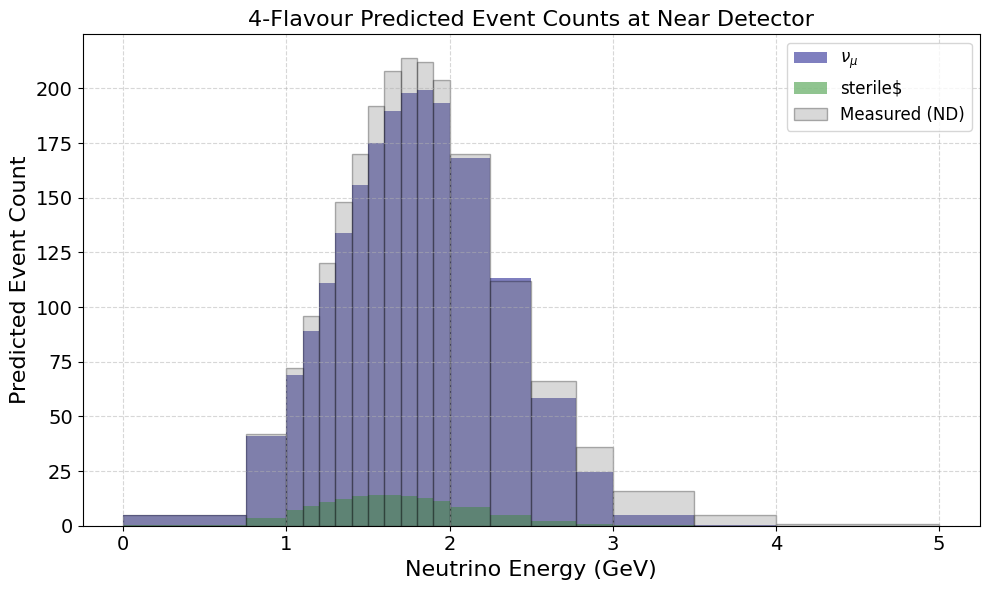

In [29]:

pred_counts_mu = gaussian_flux * prob_mm_bins
pred_counts_e  = gaussian_flux * prob_me_bins
pred_counts_tau = gaussian_flux * prob_mt_bins
pred_counts_tau = gaussian_flux * prob_mt_bins
pred_counts_s = gaussian_flux * prob_ms_bins
pred_counts_total = pred_counts_mu + pred_counts_e + pred_counts_tau

plt.figure(figsize=(10, 6))

plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
#plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, alpha=0.2, color='purple', label='Total Active')
plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.3, color='gray', label='Measured (ND)', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Count", fontsize=16)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_predicted_histograms.png", dpi=300, bbox_inches='tight')
plt.show()


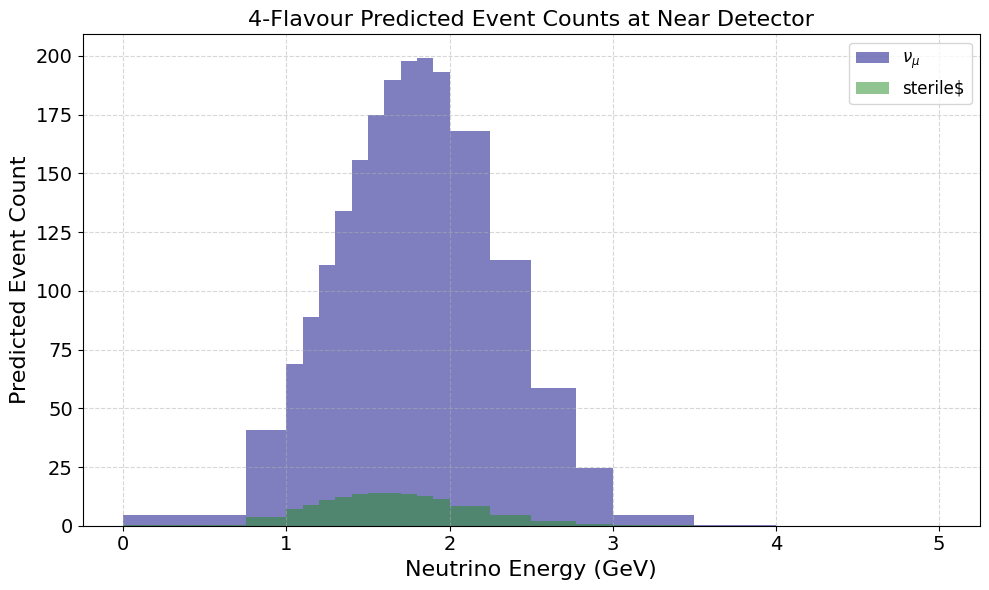

In [30]:

pred_counts_mu = gaussian_flux * prob_mm_bins
pred_counts_e  = gaussian_flux * prob_me_bins
pred_counts_tau = gaussian_flux * prob_mt_bins
pred_counts_tau = gaussian_flux * prob_mt_bins
pred_counts_s = gaussian_flux * prob_ms_bins
pred_counts_total = pred_counts_mu + pred_counts_e + pred_counts_tau

plt.figure(figsize=(10, 6))

plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
#plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, alpha=0.2, color='purple', label='Total Active')
#plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.3, color='gray', label='Measured (ND)', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=16)
plt.ylabel("Predicted Event Count", fontsize=16)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_predicted_histograms.png", dpi=300, bbox_inches='tight')
plt.show()


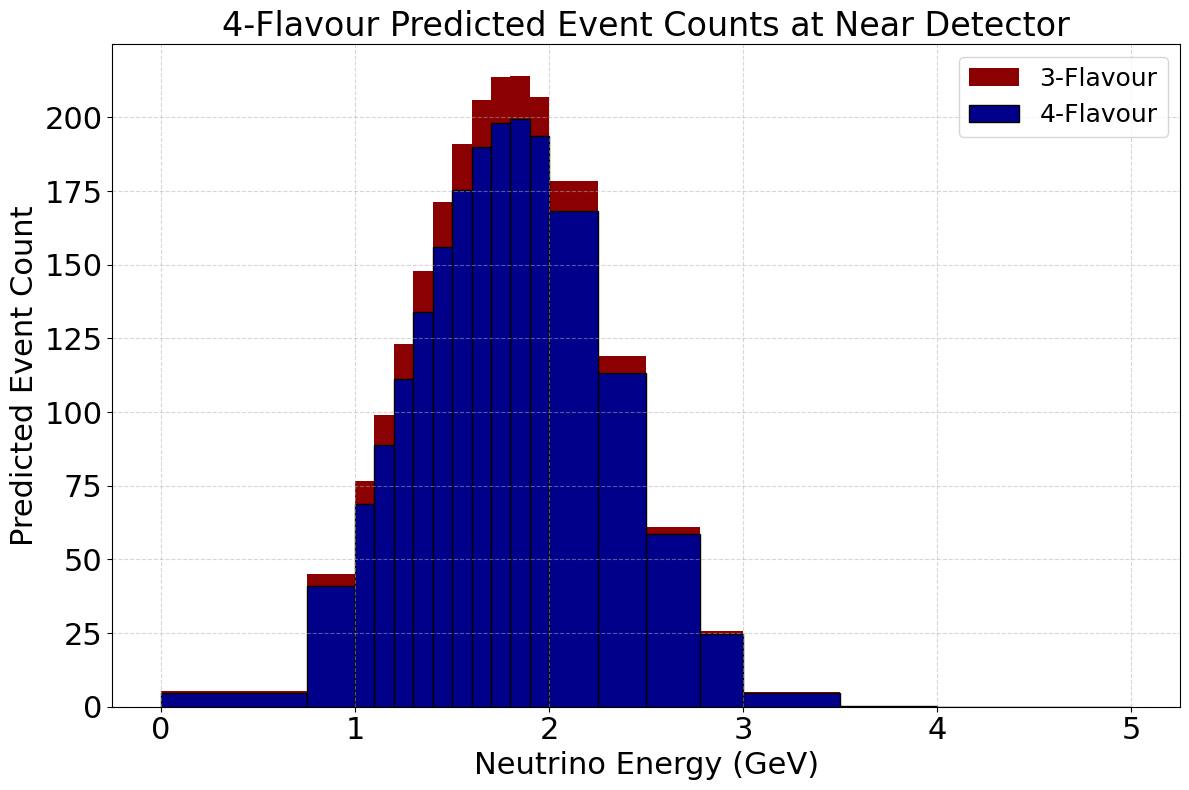

In [31]:
plt.figure(figsize=(12, 8))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
#plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    color='darkred',
    label='3-Flavour'
)
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, color='darkblue', label='4-Flavour', edgecolor = 'black')
#plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='gray', label='Measured (ND)', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Predicted Event Count", fontsize=22)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_model_spectra_comparison_cutoff.png", dpi=300, bbox_inches='tight')
plt.show()



In [32]:
files.download('4flavour_near_detector_predicted_histograms.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

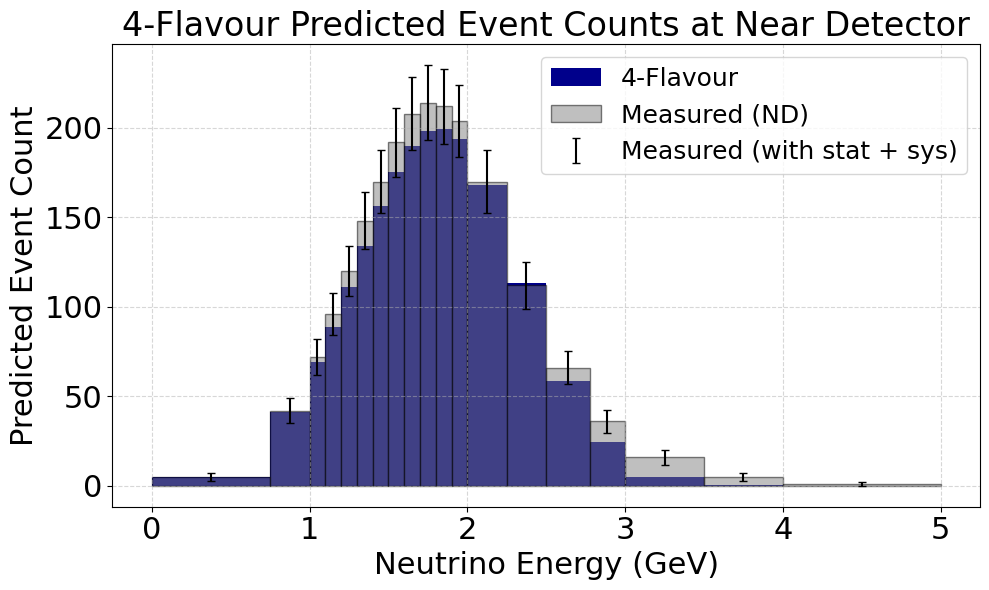

In [33]:
f_sys = 0.07  # 7% systematic uncertainty

stat_unc = np.sqrt(counts_nd)
sys_unc = f_sys * counts_nd
total_unc = np.sqrt(stat_unc**2 + sys_unc**2)

plt.figure(figsize=(10, 6))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
#plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, color='darkblue', label='4-Flavour')
plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='gray', label='Measured (ND)', edgecolor='black')
#plt.bar(bin_centers / 1e9,spectrum_all_normalized,width=np.diff(bin_edges) / 1e9,alpha=0.2,color='red',label='3-Flavour')

plt.errorbar(
    bin_centers / 1e9,
    counts_nd,
    yerr=total_unc,
    fmt=' ',
    color='black',
    label='Measured (with stat + sys)',
    capsize=3
)

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Predicted Event Count", fontsize=22)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_measured_comparison.png", dpi=300, bbox_inches='tight')
plt.show()



In [34]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

# === Inputs ===
predicted = pred_counts_total        # from 4-flavour model
measured = counts_nd                 # actual NOvA ND data

# === Chi-squared and Reduced Chi-squared ===
chi_squared = np.sum(((predicted - measured) ** 2) / (total_unc ** 2))

ndf = len(predicted) - 1  # number of degrees of freedom
reduced_chi_squared = chi_squared / ndf

# === MAE and RMSE ===
mae = mean_absolute_error(measured, predicted)
rmse = np.sqrt(mean_squared_error(measured, predicted))

# === Pearson Correlation Coefficient ===
pearson_r, _ = pearsonr(measured, predicted)

# === Print the results ===
print(f"Chi-squared: {chi_squared:.2f}")
print(f"Reduced Chi-squared: {reduced_chi_squared:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Pearson Correlation Coefficient (r): {pearson_r:.3f}")


Chi-squared: 21.53
Reduced Chi-squared: 1.20
MAE: 8.47
RMSE: 10.25
Pearson Correlation Coefficient (r): 0.998


In [35]:
files.download('4flavour_near_detector_measured_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

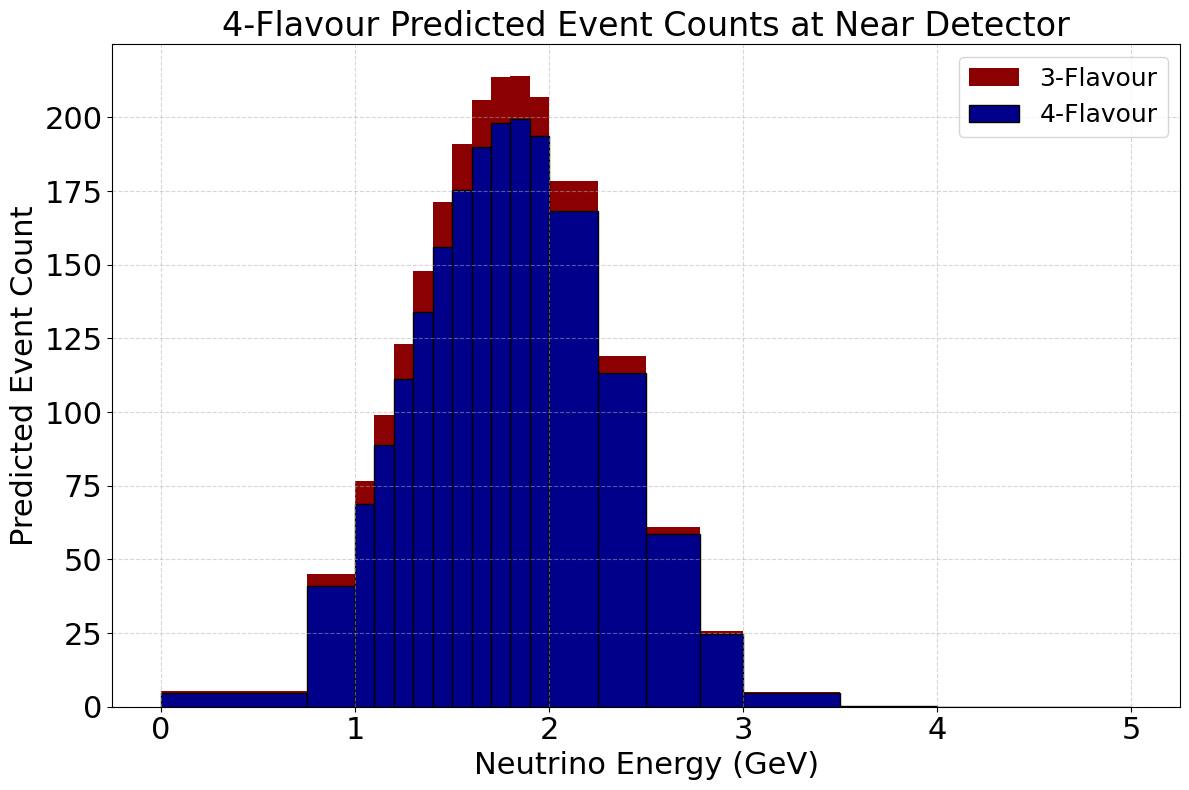

In [36]:
plt.figure(figsize=(12, 8))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
#plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    color='darkred',
    label='3-Flavour'
)
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, color='darkblue', label='4-Flavour', edgecolor = 'black')
#plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='gray', label='Measured (ND)', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Predicted Event Count", fontsize=22)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_predicted_histograms.png", dpi=300, bbox_inches='tight')
plt.show()



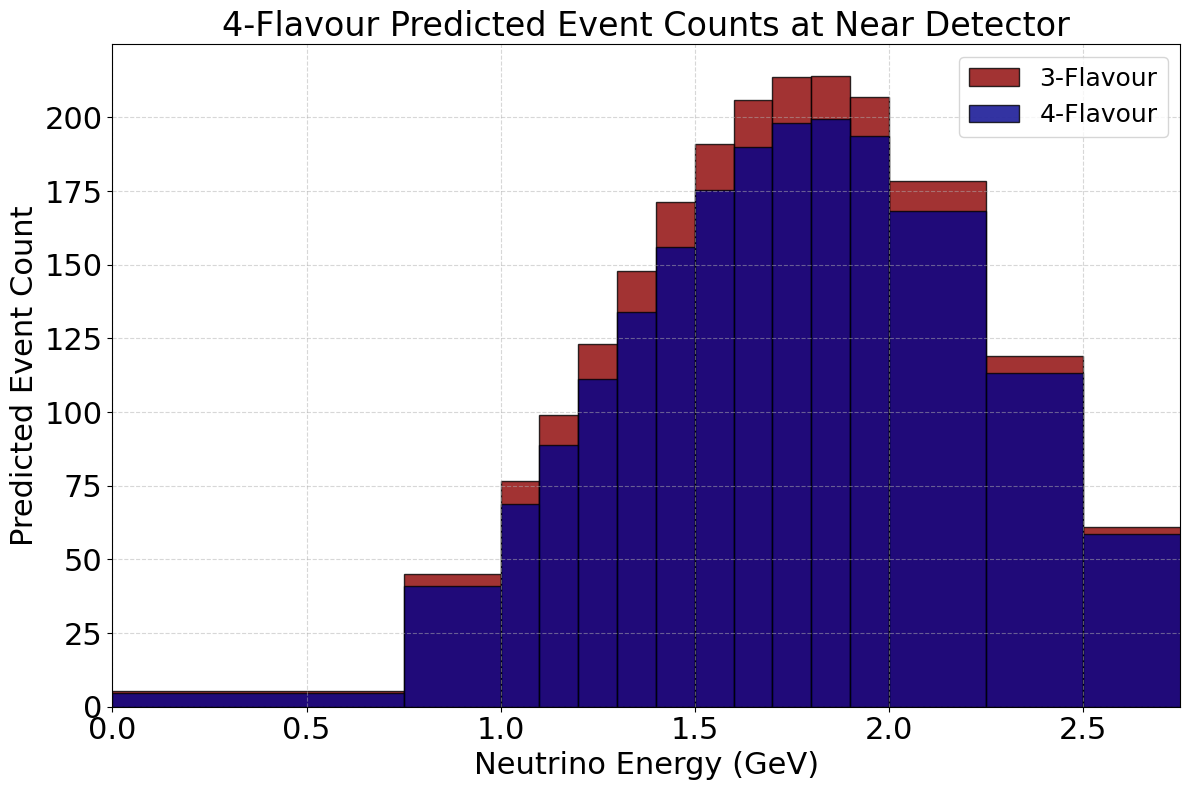

In [37]:
plt.figure(figsize=(12, 8))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
#plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
plt.bar(
    bin_centers / 1e9,
    spectrum_all_normalized,
    width=np.diff(bin_edges) / 1e9,
    color='darkred',
    label='3-Flavour',
    edgecolor='black',
    alpha = 0.8
)
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, color='darkblue', label='4-Flavour', edgecolor = 'black', alpha = 0.8)
#plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='gray', label='Measured (ND)', edgecolor='black')

plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Predicted Event Count", fontsize=22)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 2.75)
plt.tight_layout()
plt.savefig("4flavour_vs_3flavour_near_detector_predicted_histograms_comp.png", dpi=300, bbox_inches='tight')
plt.show()



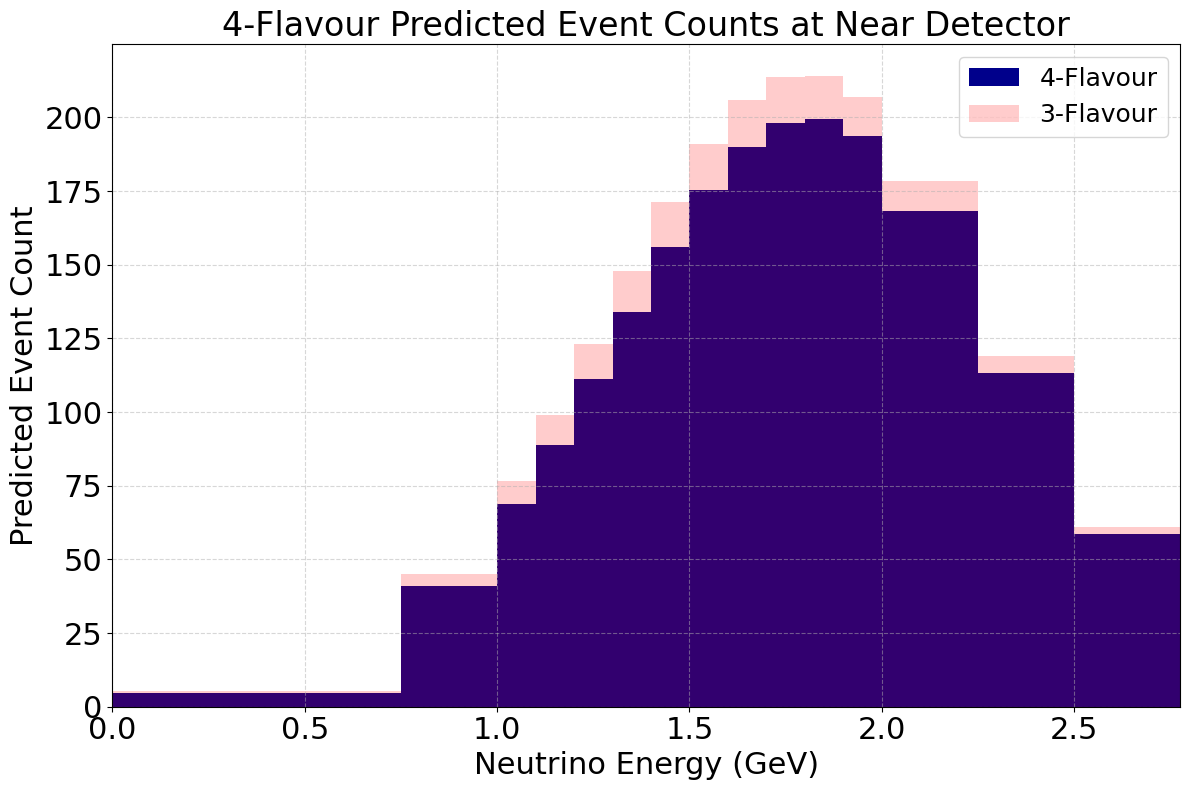

In [38]:
plt.figure(figsize=(12, 8))

#plt.bar(bin_centers / 1e9, pred_counts_mu, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='navy', label=r"$\nu_\mu$")
#plt.bar(bin_centers / 1e9, pred_counts_e, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='orangered', label=r"$\nu_e$")
#plt.bar(bin_centers / 1e9, pred_counts_tau, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"$\nu_\tau$")
#plt.bar(bin_centers / 1e9, pred_counts_s, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='forestgreen', label=r"sterile$")
plt.bar(bin_centers / 1e9, pred_counts_total, width=np.diff(bin_edges) / 1e9, color='darkblue', label='4-Flavour')
#plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, alpha=0.5, color='gray', label='Measured (ND)', edgecolor='black')
plt.bar(bin_centers / 1e9,spectrum_all_normalized,width=np.diff(bin_edges) / 1e9,alpha=0.2,color='red',label='3-Flavour')
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Predicted Event Count", fontsize=22)
plt.title("4-Flavour Predicted Event Counts at Near Detector", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=18)
plt.xlim(0,2.775)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("4flavour_near_detector_measured_comparison.png", dpi=300, bbox_inches='tight')
plt.show()



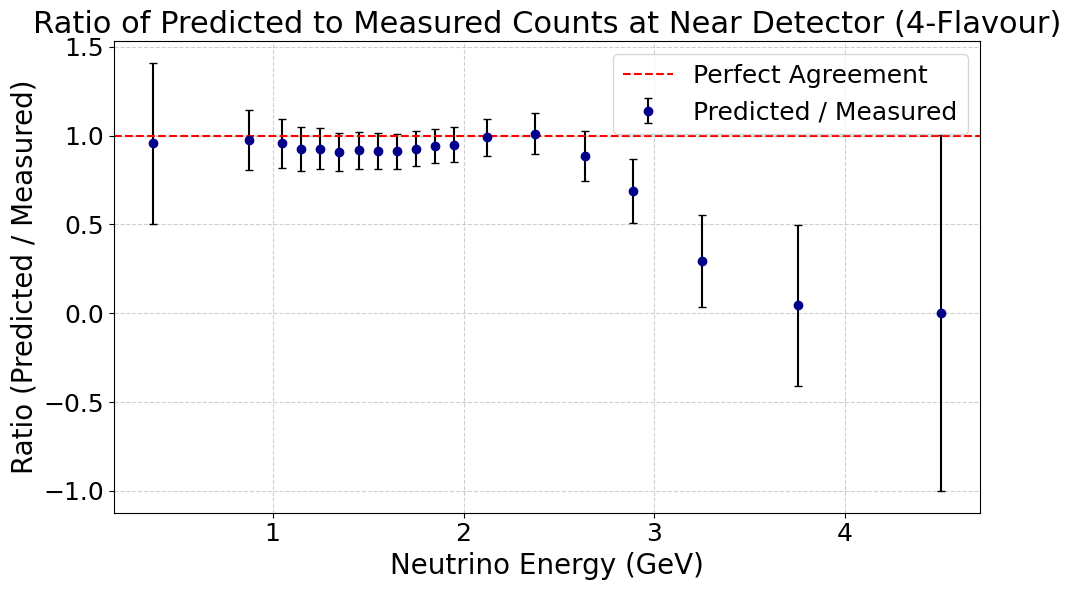

In [39]:
# RATIO (PREDICTED / MEASURED) FOR FOUR-FLAVOUR
mask_4f = counts_nd > 0

ratios_4f = np.full_like(counts_nd, np.nan, dtype=float)
ratio_unc_4f = np.full_like(counts_nd, np.nan, dtype=float)

ratios_4f[mask_4f] = pred_counts_total[mask_4f] / counts_nd[mask_4f]
ratio_unc_4f[mask_4f] = total_unc[mask_4f] / counts_nd[mask_4f]

plt.figure(figsize=(10, 6))
plt.errorbar(
    bin_centers / 1e9,
    ratios_4f,
    yerr=ratio_unc_4f,
    fmt='o',
    color='darkblue',
    ecolor='black',
    capsize=3,
    elinewidth=1.5,
    label='Predicted / Measured'
)

plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Perfect Agreement')

plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Ratio (Predicted / Measured)", fontsize=20)
plt.title("Ratio of Predicted to Measured Counts at Near Detector (4-Flavour)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig("ratio_predicted_measured_ND_4flavour.png", dpi=300, bbox_inches='tight')
plt.show()


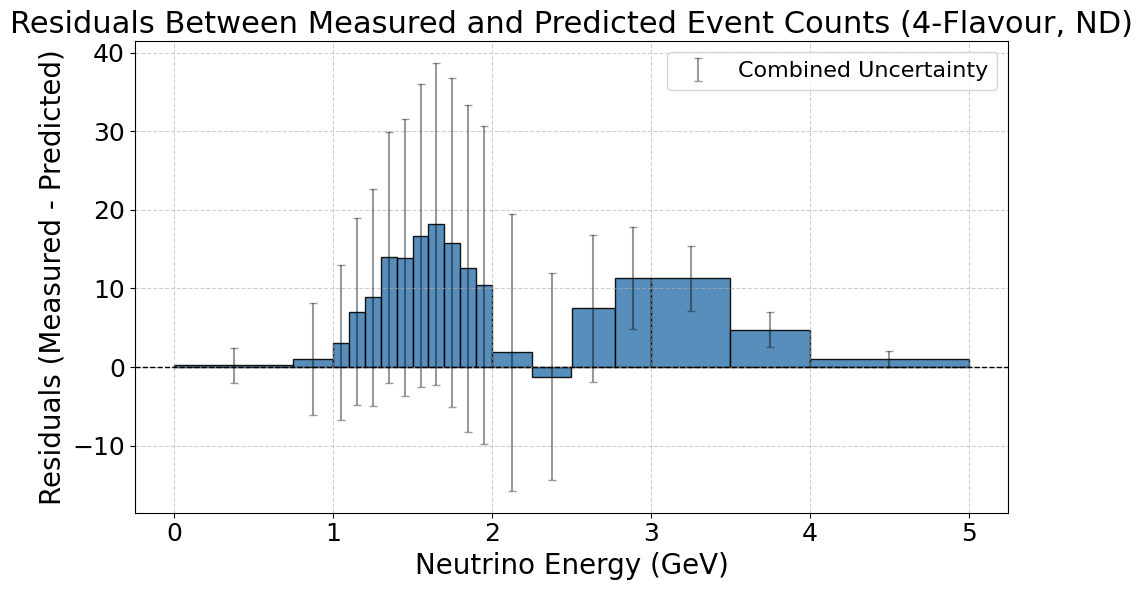

In [40]:
# RESIDUALS FOR FOUR-FLAVOUR
residuals_4f = counts_nd - pred_counts_total

plt.figure(figsize=(10, 6))
plt.bar(bin_centers / 1e9, residuals_4f, width=np.diff(bin_edges) / 1e9, color='steelblue', alpha=0.9, edgecolor='black')
plt.errorbar(bin_centers / 1e9, residuals_4f, yerr=total_unc, fmt=' ', color='black', capsize=3, alpha=0.4, label='Combined Uncertainty')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Neutrino Energy (GeV)", fontsize=20)
plt.ylabel("Residuals (Measured - Predicted)", fontsize=20)
plt.title("Residuals Between Measured and Predicted Event Counts (4-Flavour, ND)", fontsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("4flavour_residuals_ND.png", dpi=300, bbox_inches='tight')
plt.show()


In [41]:
files.download('4flavour_residuals_ND.png')
files.download('ratio_predicted_measured_ND_4flavour.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

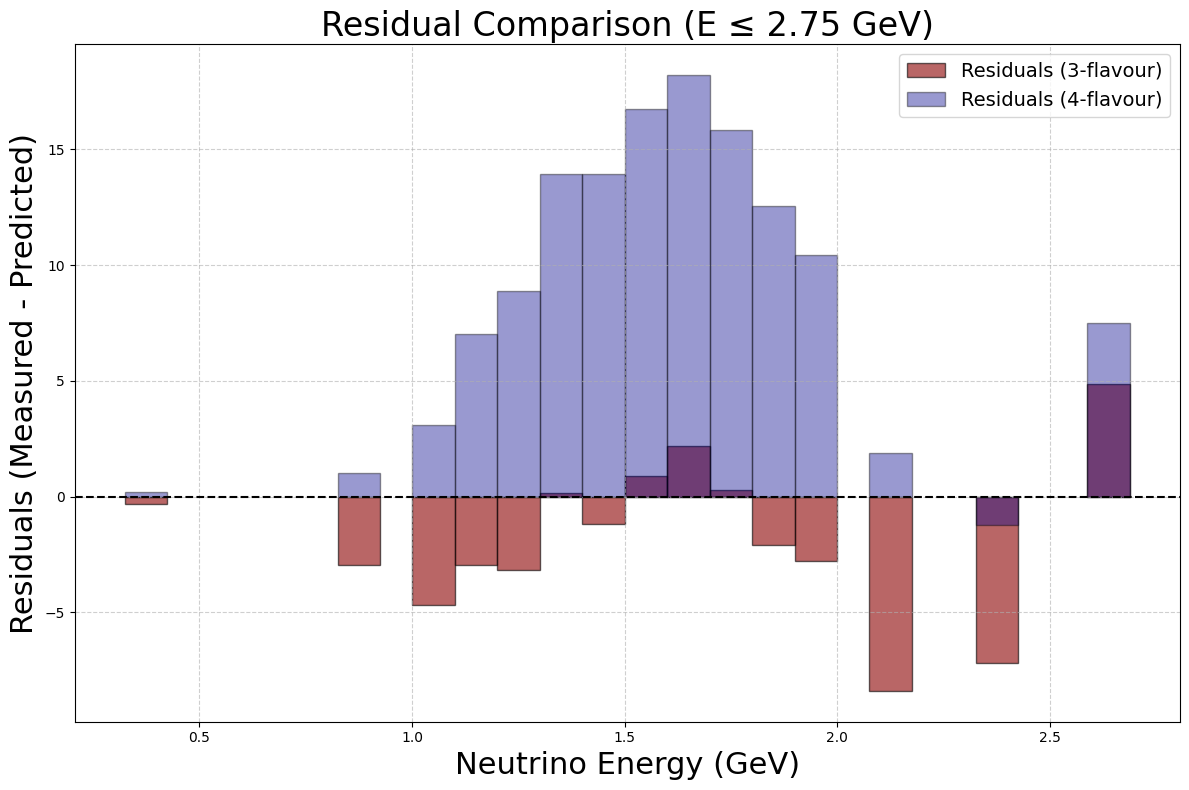

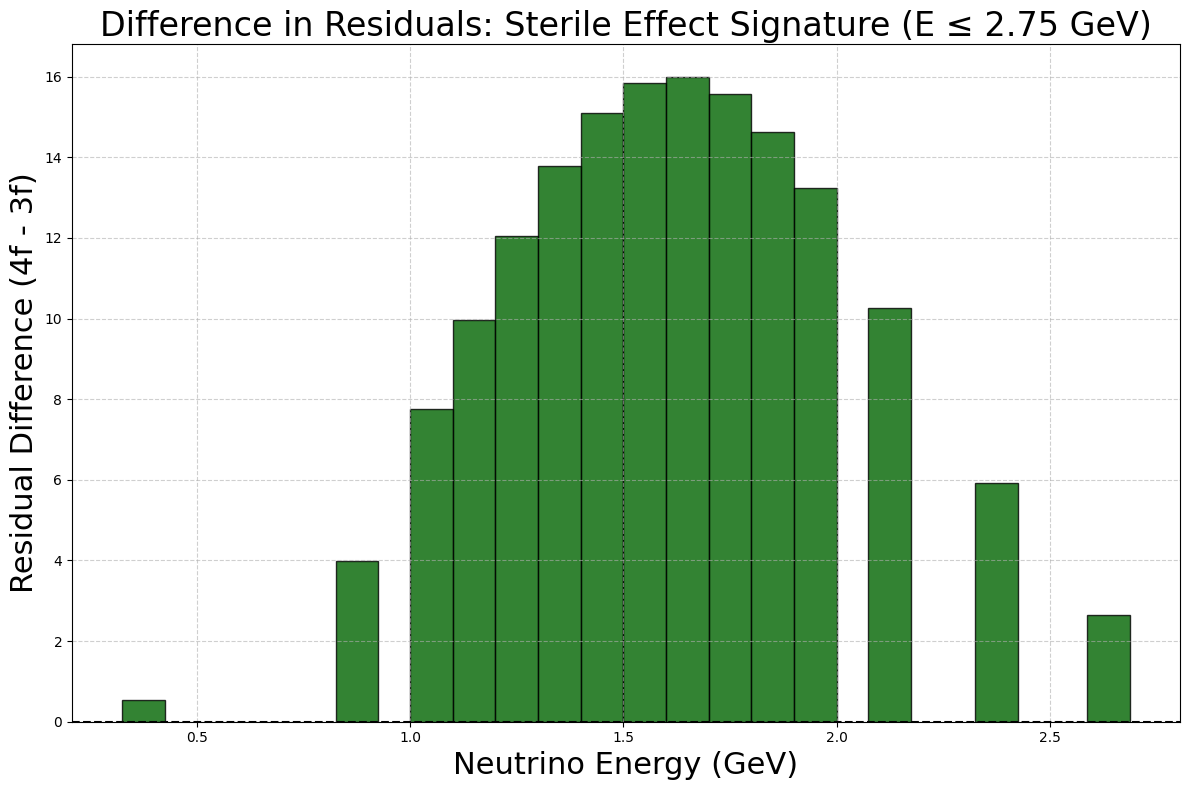

In [42]:
# Restricting to E <= 2.75 GeV
energy_cut = 2.75  # GeV
mask = (bin_centers / 1e9) <= energy_cut

bin_centers_cut = bin_centers[mask]
spec_3f_cut = spectrum_all_normalized[mask]
spec_4f_cut = pred_counts_total[mask]
counts_nd_cut = counts_nd[mask]
unc_cut = total_unc[mask]

# Residuals
resid_3f = counts_nd_cut - spec_3f_cut
resid_4f = counts_nd_cut - spec_4f_cut
delta_resid = resid_4f - resid_3f

# Plotting residuals comparison
plt.figure(figsize=(12, 8))
plt.bar(bin_centers_cut / 1e9, resid_3f, width=0.1, alpha=0.6, label='Residuals (3-flavour)', color='darkred', edgecolor='black')
plt.bar(bin_centers_cut / 1e9, resid_4f, width=0.1, alpha=0.4, label='Residuals (4-flavour)', color='darkblue', edgecolor = 'black')
#plt.errorbar(bin_centers_cut / 1e9, resid_4f, yerr=unc_cut, fmt=' ', color='black', capsize=3, label='Combined Uncertainty')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Residuals (Measured - Predicted)", fontsize=22)
plt.title("Residual Comparison (E ≤ 2.75 GeV)", fontsize=24)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("model_residual_comparison.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Plotting delta residuals
plt.figure(figsize=(12, 8))
plt.bar(bin_centers_cut / 1e9, delta_resid, width=0.1, color='darkgreen', alpha=0.8, edgecolor = 'black')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Residual Difference (4f - 3f)", fontsize=22)
plt.title("Difference in Residuals: Sterile Effect Signature (E ≤ 2.75 GeV)", fontsize=24)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("model_residuals_diff_comparisonND.png", dpi=300, bbox_inches='tight')
plt.show()

In [43]:
files.download('4flavour_vs_3flavour_near_detector_predicted_histograms_comp.png')
files.download('model_residual_comparison.png')
files.download('model_residuals_diff_comparisonND.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

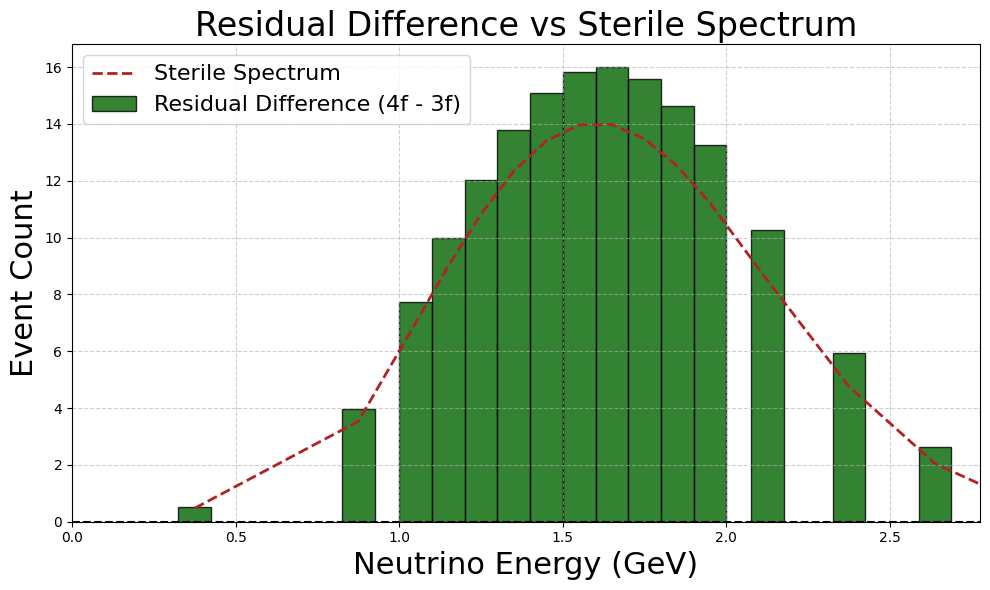

In [44]:
mask_sterile = (bin_centers / 1e9) <= 3.0
bin_centers_sterile = bin_centers[mask_sterile]
sterile_spectrum_cut = spectrum_ms[mask_sterile]

plt.figure(figsize=(10, 6))
plt.bar(bin_centers_cut / 1e9, delta_resid, width=0.1, color='darkgreen', alpha=0.8,
        label='Residual Difference (4f - 3f)', edgecolor='black')

plt.plot(bin_centers_sterile / 1e9, sterile_spectrum_cut, color='firebrick', linewidth=2,
         linestyle='--', label='Sterile Spectrum')

plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Neutrino Energy (GeV)", fontsize=22)
plt.ylabel("Event Count", fontsize=22)
plt.title("Residual Difference vs Sterile Spectrum", fontsize=24)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0,2.775)
plt.tight_layout()
plt.savefig("residual_vs_sterile_overlay.png", dpi=300, bbox_inches='tight')
plt.show()



In [45]:
from scipy.stats import pearsonr

r, _ = pearsonr(delta_resid, sterile_spectrum_cut[:len(delta_resid)])
print(f"Pearson correlation between ΔResidual and sterile spectrum: {r:.3f}")


Pearson correlation between ΔResidual and sterile spectrum: 0.998


In [190]:
files.download('model_residual_comparison.png')
files.download('residual_vs_sterile_overlay.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>